#**Pre-request**

##Mount google drive


In [ ]:
### **Mount** Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install pakages


In [ ]:
#Install pakages
project_path = "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
!cat "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt"
!pip install  -r "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt" --no-cache-dir
%cd $project_path





torch
transformers
huggingface_hub
datasets
timm
patool
sktime
reformer_pytorch
optuna
ptflopsRequirement already satisfied: torch in /usr/local/lib/python3.12/dist-packages (from -r /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/requirement/Install/NASEnhancedPretraindMLModleAdvance.txt (line 1)) (2.11.0+cu128)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 309.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 369.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 367.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 380.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 353.3 MB/s eta 0:00:00
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection


##Import  libs

In [ ]:
# =====================================================
# ⏱️ Runtime & System Utilities
# =====================================================
import os
import sys
import time
import logging
import hashlib
import shutil
import subprocess
import warnings
from datetime import datetime
from argparse import Namespace

# Start timer
start_time = time.time()

# =====================================================
# 📦 Core Data Handling
# =====================================================
import numpy as np
import pandas as pd
import yaml

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# =====================================================
# 📊 Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# ⚙️ Machine Learning (Scikit-learn)
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    cohen_kappa_score
)

# =====================================================
# 🌲 Gradient Boosting
# =====================================================
from xgboost import XGBClassifier
import joblib

# =====================================================
# 🔥 Deep Learning (PyTorch)
# =====================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast
from torch.utils.flop_counter import FlopCounterMode

# =====================================================
# 🧠 Deep Learning (TensorFlow / Keras)
# =====================================================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout, Layer
from tensorflow.keras.optimizers import Adam

# =====================================================
# 🤗 Transformers & Time Series
# =====================================================
from transformers import AutoModel
from sktime.datasets import load_from_tsfile_to_dataframe

# =====================================================
# 📈 Model Complexity / FLOPs
# =====================================================
from ptflops import get_model_complexity_info

# =====================================================
# 📊 Data Pipeline (Custom)
# =====================================================
sys.path.append('/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library')

from models.TimesNet import Model as TimesNetModel
from data_provider.data_factory import data_provider

# =====================================================
# 🧠 Explainability
# =====================================================
import shap

# =====================================================
# 📊 Utilities & Progress
# =====================================================
from tqdm import tqdm

# =====================================================
# 📊 Google Colab (Optional)
# =====================================================
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    data_table.DataTable.max_columns = 50
    data_table.DataTable.max_rows = 150
except ImportError:
    pass

# =====================================================
# ✅ Ready
# =====================================================
print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


##Confirmation setup

In [ ]:
# =====================================================
# 🎲 Random Seeds (Reproducibility)
# =====================================================
!nvidia-smi                # confirm GPU
!pip show torch  # confirm versions
torch.manual_seed(42)
np.random.seed(42)

Wed Jul  8 10:01:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   37C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Read Config file

In [ ]:

logger = logging.getLogger(__name__)

def load_config(config_path="configs/baseline.yaml"):
    """Load YAML config file and expand ${root_path} placeholders."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    logger.info(f"✅ Loaded config from {config_path}")

    # --- Expand ${root_path} placeholders ---
    root = config.get("root_path", "")

    def expand_paths(obj):
        if isinstance(obj, dict):
            return {k: expand_paths(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [expand_paths(i) for i in obj]
        elif isinstance(obj, str) and "${root_path}" in obj:
            return obj.replace("${root_path}", root)
        else:
            return obj

    config = expand_paths(config)
    return config
config = load_config(os.path.join(project_path, "configs", "baseline.yaml"))


## Set Variables

In [ ]:
max_seq_len = 4                  # Maximum sequence length
recent_mode = False               # False → oldest mode, True → recent-window mode
# n_jobs=-1
num_classes = 2                   # Binary classification
epochs = 20                       # Maximum training epochs

# ----------------------------------------------------------
# 📊 Evaluation Settings
# ----------------------------------------------------------
correlation_threshold = 0.85      # Feature correlation threshold

# ----------------------------------------------------------
# 📈 Progressive Evaluation
# ----------------------------------------------------------
method = "linear"                 # Interpolation method for key_rounds
n_points = 10                     # Number of evaluation points

# ----------------------------------------------------------
# 💾 Paths
# ----------------------------------------------------------
model_path = config['ML']['models']

# ==========================================================
# ✅ Configuration Summary
# ==========================================================
print("="*60)
print("📋 CONFIGURATION SUMMARY")
print("="*60)
print(f"  Sequence length:  {max_seq_len}")
print(f"  Mode:             {'Recent' if recent_mode else 'Oldest'}")
print(f"  Model path:       {model_path}")
print("="*60)

# Global unified results table for all models
results_table = pd.DataFrame(columns=["NAS SL", "Testing SL","Model","F1", "AUC", "Recall","Precision" ,"threshold","Round"])
summary = pd.DataFrame(
    columns=[
        "NAS SL",
        "Testing SL",
        "Model",
        "F1",
        "AUC",
        "Recall",
        "Precision",
        "threshold"
    ]
)


📋 CONFIGURATION SUMMARY
  Sequence length:  4
  Mode:             Oldest
  Model path:       /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/


##Models Paramters

In [ ]:


# ==================================================
# Base_SL = 4
# ==================================================

Base_SL = '4M'

timesnet_parameters = {
    "learning_rate": 0.0001,
    "d_model":       32,
    "d_ff":          32,
    "e_layers":      2,
    "top_k":         2,
    "dropout":       0.1,
    "batch_size":    8,
    "patience":      3,
    "num_kernels":   6,
}

lstm_parameters = {
    "learning_rate": 0.001,
    "d_model":       64,
    "d_ff":          128,
    "e_layers":      3,
    "dropout":       0.2,
    "batch_size":    8,
    "patience":      3,
}

transformer_parameters = {
    "learning_rate": 0.000936,
    "d_model":       48,
    "n_heads":       8,
    "d_ff":          4,
    "e_layers":      2,
    "dropout":       0.387,
    "batch_size":    8,
    "patience":      5,
}

xgb_parameters = {
    "n_estimators":     500,
    "max_depth":        4,
    "learning_rate":    0.01,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "gamma":            0.1,
    "patience":         3,
    "eval_metric":      "logloss",
}

rf_parameters = {
    "n_estimators":      200,
    "max_depth":         5,
    "min_samples_split": 10,
    "min_samples_leaf":  5,
}


In [ ]:

# ✅ Unpack timesnet_parameters into simple variables for shell script
_tn_patience      = timesnet_parameters["patience"]
_tn_batch_size    = timesnet_parameters["batch_size"]
_tn_learning_rate = timesnet_parameters["learning_rate"]
_tn_e_layers      = timesnet_parameters["e_layers"]
_tn_d_model       = timesnet_parameters["d_model"]
_tn_d_ff          = timesnet_parameters["d_ff"]
_tn_top_k         = timesnet_parameters["top_k"]
_tn_dropout       = timesnet_parameters["dropout"]
_tn_num_kernels = timesnet_parameters["num_kernels"]


## Helpers

In [ ]:

def append_to_summary(summary, model_name, results):
    """
    Appends or updates the summary table with model results.
    Works with both capitalized and lowercase keys automatically.
    """
    # ✅ Create summary DataFrame if missing
    if summary is None or not isinstance(summary, pd.DataFrame):
          summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    # Ensure "Model" column exists (prevents KeyError)
    if "Model" not in summary.columns:
        summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])

    # ✅ Normalize key names to lowercase
    results = {k.lower(): v for k, v in results.items()}

    # ✅ Remove any existing row for the same model
    summary = summary[summary["Model"] != model_name]

    # ✅ Add new row (robust to missing values)
    row = {
        "NAS SL":Base_SL,
        "Testing SL": max_seq_len,
        "Model": model_name,
        "F1": round(results.get("f1", np.nan), 4) if not pd.isna(results.get("f1", np.nan)) else np.nan,
        "AUC": round(results.get("auc", np.nan), 4) if not pd.isna(results.get("auc", np.nan)) else np.nan,
        "Recall": round(results.get("recall", np.nan), 4) if not pd.isna(results.get("recall", np.nan)) else np.nan,
        "Precision": round(results.get("precision", np.nan), 4) if not pd.isna(results.get("precision", np.nan)) else np.nan,
        "Threshold": round(results.get("threshold", np.nan), 4) if not pd.isna(results.get("threshold", np.nan)) else np.nan
    }


    # ✅ Append and reindex
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = summary.reindex(columns=["NAS SL","Testing SL","Model","F1", "AUC", "Recall", "Precision",  "Threshold"])
    return summary

def plot_feature_importance(model, X_train, model_name="Model", top_n=20):
    """
    Plot feature importance for tree-based models (XGBoost, RandomForest).
    """


    # Handle model type
    if hasattr(model, "get_booster"):  # XGBoost
        importance = model.get_booster().get_score(importance_type='gain')
        fi = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        })
    elif hasattr(model, "feature_importances_"):  # RandomForest
        fi = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': model.feature_importances_
        })
    else:
        raise ValueError(f"{model_name} does not support feature importance extraction.")

    # Sort and plot
    fi = fi.sort_values(by='Importance', ascending=False)
    display(fi.head(10))

    plt.figure(figsize=(10,6))
    plt.barh(fi['Feature'][:top_n][::-1], fi['Importance'][:top_n][::-1])
    plt.title(f'📊 {model_name} Feature Importance (Top {top_n})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    return fi




def find_best_threshold(y_true, probs, low=0.2, high=0.8, n=61):
    best_f1 = -1.0
    best_thr = 0.5
    for thr in np.linspace(low, high, n):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


def plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col=None,
    figsize=(14, 6)
):
    """
    Plot progressive evaluation metrics per round for multiple models.

    Parameters
    ----------
    results_table : pd.DataFrame
        Must contain columns: Model, metrics, and either Round or input_size
    metrics : tuple
        Metrics to plot (default: AUC, Recall, F1)
    round_col : str or None
        Column name for x-axis. If None, auto-detects.
    figsize : tuple
        Figure size for plots
    """

    # --------------------------------------------------
    # Auto-detect round column
    # --------------------------------------------------
    if round_col is None:
        if "Round" in results_table.columns:
            round_col = "Round"
        elif "input_size" in results_table.columns:
            round_col = "input_size"
        else:
            raise ValueError("No Round or input_size column found.")

    # --------------------------------------------------
    # Sort results (important for correct curves)
    # --------------------------------------------------
    results_table = results_table.sort_values(
        by=[round_col, "Model"],
        ascending=True
    ).reset_index(drop=True)


    # --------------------------------------------------
    # Plot each metric
    # --------------------------------------------------
    for metric in metrics:

        plt.figure(figsize=figsize)

        for model in results_table["Model"].unique():
            subset = (
                results_table[results_table["Model"] == model]
                .sort_values(by=round_col)
            )

            plt.plot(
                subset[round_col],
                subset[metric],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model,
                alpha=0.85
            )

        plt.title(f"{metric} per {round_col}", fontsize=18)
        plt.xlabel(round_col, fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.4)

        # Legend outside
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=4,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()
    display(results_table)

    return results_table

# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

def get_key_rounds(max_seq_len, method="linear", n_points=5):
    """
    Generate scientifically meaningful evaluation checkpoints.

    Args:
        max_seq_len: Maximum sequence length (16, 100, 300, etc.)
        method: Selection strategy
            - "linear": Equal spacing (1, 25%, 50%, 75%, 100%)
            - "logarithmic": More points early (where changes happen fast)
            - "sqrt": Square root spacing (balanced)
            - "percentile": Fixed percentages
        n_points: Number of evaluation points (default 5)

    Returns:
        List of round numbers to evaluate
    """

    if max_seq_len <= n_points:
        # If sequence is short, evaluate all rounds
        return list(range(1, max_seq_len + 1))

    if method == "linear":
        # Equal spacing: 1, 25%, 50%, 75%, 100%
        rounds = np.linspace(1, max_seq_len, n_points)

    elif method == "logarithmic":
        # More points early (fraud detection often shows early signal)
        # Log scale: 1, 2, 4, 8, 16 style
        rounds = np.logspace(0, np.log10(max_seq_len), n_points)

    elif method == "sqrt":
        # Square root spacing (balanced between linear and log)
        rounds = np.square(np.linspace(1, np.sqrt(max_seq_len), n_points))

    elif method == "percentile":
        # Fixed percentages: 1st event, 10%, 25%, 50%, 75%, 100%
        percentages = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
        rounds = [max(1, int(p * max_seq_len)) for p in percentages]
        return sorted(set(rounds))  # Remove duplicates

    elif method == "early_focus":
        # Focus on early detection (more points in first half)
        # Useful for fraud detection where early signal matters
        early = np.linspace(1, max_seq_len * 0.5, n_points - 2)
        late = [max_seq_len * 0.75, max_seq_len]
        rounds = np.concatenate([early, late])

    else:
        raise ValueError(f"Unknown method: {method}")

    # Convert to integers, ensure valid range, remove duplicates
    rounds = [int(round(r)) for r in rounds]
    rounds = [max(1, min(r, max_seq_len)) for r in rounds]
    rounds = sorted(set(rounds))

    # Always include 1 and max_seq_len
    if 1 not in rounds:
        rounds = [1] + rounds
    if max_seq_len not in rounds:
        rounds = rounds + [max_seq_len]

    return rounds


# ============================================================
# General Metric + Gap Helpers
# ============================================================


def get_timesnet_val_threshold(results_dir):
    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    if not os.path.exists(val_prob_path) or not os.path.exists(val_true_path):
        raise FileNotFoundError(
            f"Missing validation probability files in {results_dir}. "
            f"Expected val_prob.npy and val_true.npy"
        )

    val_probs = np.load(val_prob_path)
    val_true = np.load(val_true_path)

    best_thr, best_f1 = find_best_threshold(val_true, val_probs)
    return best_thr, best_f1


gap_table = pd.DataFrame(columns=[
    "Model",
    "Train_F1", "Val_F1", "Test_F1",
    "Train_vs_Val_Gap",
    "Train_vs_Test_Gap",
    "Val_vs_Test_Gap",
    "Threshold"
])

def evaluate_probs(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "F1": f1_score(y_true, preds, zero_division=0),
        "AUC": roc_auc_score(y_true, probs),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "Precision": precision_score(y_true, preds, zero_division=0)
    }

def append_gap_result(gap_table, model_name, train_f1, val_f1, test_f1, threshold):
    row = {
        "Model": model_name,
        "Train_F1": round(train_f1, 4),
        "Val_F1": round(val_f1, 4),
        "Test_F1": round(test_f1, 4),
        "Train_vs_Val_Gap": round(train_f1 - val_f1, 4),
        "Train_vs_Test_Gap": round(train_f1 - test_f1, 4),
        "Val_vs_Test_Gap": round(val_f1 - test_f1, 4),
        "Threshold": round(threshold, 4)
    }

    gap_table = gap_table[gap_table["Model"] != model_name]
    gap_table = pd.concat([gap_table, pd.DataFrame([row])], ignore_index=True)
    return gap_table

def plot_probability_distribution(model_name, val_probs, test_probs, threshold, debug=True):
    val_probs = np.asarray(val_probs).flatten()
    test_probs = np.asarray(test_probs).flatten()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(val_probs, bins=50, alpha=0.7)
    plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.2f}")
    plt.title(f"{model_name} Validation Probability")
    plt.xlabel("Fraud Probability")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(test_probs, bins=50, alpha=0.7)
    plt.axvline(threshold, linestyle="--", label=f"Threshold={threshold:.2f}")
    plt.title(f"{model_name} Test Probability")
    plt.xlabel("Fraud Probability")
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

def print_detailed_report(model_name, y_true, y_pred):
    print("\n" + "="*60)
    print(f"📊 Detailed Report: {model_name}")
    print("="*60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Fraud"],
        digits=4,
        zero_division=0
    ))

## Drop and select features

In [ ]:
# def prepare_features(df):
#     """
#     Selects only the explicitly defined features for model training.
#     You control which features are used by editing 'selected_features' below.
#     """

#     # --- Define selected features manually ---
#     selected_features = [
#         "window_size", "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
#        "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
#        "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
#        "sms_calltype_ratio", "app_months_active", "app_total_flow", "app_avg_flow",
#        "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max", "user_months_active",
#         "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt", "snapshot_round"
#    ]

#     # --- Keep only existing columns ---
#     available = [f for f in selected_features if f in df.columns]
#     missing = [f for f in selected_features if f not in df.columns]

#     X = df[available].copy()

#     #print(f"\n📊 Final features used ({len(available)}): {available}")
#     if missing:
#         print(f"⚠️ Missing columns not found in data: {missing}")

#     return X


## Key Rounds

In [ ]:
# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

key_rounds = get_key_rounds(max_seq_len, method=method, n_points=n_points)
print(f"📊 Evaluating rounds: {key_rounds}")
print(f"   Total: {len(key_rounds)} rounds instead of {max_seq_len}")

📊 Evaluating rounds: [1, 2, 3, 4]
   Total: 4 rounds instead of 4


#ML Modules

### Load

In [ ]:
def load_raw_datasets(config):


    if "ML" in config and "Events" in config["ML"]:
        events_cfg = config["ML"]["Events"]
    else:
        events_cfg = config["Events"]

    base = events_cfg["base_path"]
    files = events_cfg["files"]

    # --- Load all datasets ---
    df_voc = pd.read_csv(os.path.join(base, files["voc"]))
    df_sms = pd.read_csv(os.path.join(base, files["sms"]))
    df_app = pd.read_csv(os.path.join(base, files["app"]))
    df_user = pd.read_csv(os.path.join(base, files["user"]))

    # --- Normalize timestamps and add source column ---
    for df, src in [(df_voc, "VOC"), (df_sms, "SMS"), (df_app, "APP"), (df_user, "USER")]:
        df["source"] = src
        ts_col = [c for c in df.columns if "time" in c.lower()][0]
        df.rename(columns={ts_col: "event_time"}, inplace=True)
        df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    print("✅ Raw datasets loaded and timestamp-normalized.")
    return df_voc, df_sms, df_app, df_user

df_voc, df_sms, df_app, df_user = load_raw_datasets(config)


✅ Raw datasets loaded and timestamp-normalized.


### Build timeline (events)

In [ ]:
def merge_and_prepare_events(df_voc, df_sms, df_app, df_user):

    # --- 1️⃣ Normalize USER dataset ---
    if 'label' not in df_user.columns:
        raise KeyError("❌ 'label' column not found in user dataset")

    # Ensure numeric consistency
    df_user['label'] = df_user['label'].fillna(0).astype(int)
    df_user['idcard_cnt'] = df_user['idcard_cnt'].fillna(0).astype(float)
    df_user['arpu_value'] = df_user['arpu_value'].fillna(0).astype(float)

    # --- 2️⃣ Extract static info for merging (label + sim count only) ---
    #static_user_info = df_user.groupby("phone_no_m", as_index=False)[["label", "idcard_cnt"]].max()
    # --- 2️⃣ Extract static info from the RAW user table (covers all 6,106 users) ---
    lbl_cfg = config["ML"]["labels"]
    raw_user = pd.read_csv(os.path.join(lbl_cfg["base_path"], lbl_cfg["file"]))
    static_user_info = raw_user[["phone_no_m", "label", "idcard_cnt"]].drop_duplicates("phone_no_m")
    static_user_info["label"] = static_user_info["label"].astype(int)
    static_user_info["idcard_cnt"] = static_user_info["idcard_cnt"].fillna(0).astype(float)

    # --- 3️⃣ Merge static info into other event tables ---
    df_voc = df_voc.merge(static_user_info, on="phone_no_m", how="left")
    df_sms = df_sms.merge(static_user_info, on="phone_no_m", how="left")
    df_app = df_app.merge(static_user_info, on="phone_no_m", how="left")


    # --- 4️⃣ Combine all transactional event sources ---
    # include df_user itself since arpu_value is event-like
    events = pd.concat([df_voc, df_sms, df_app, df_user], ignore_index=True)

    # --- 5️⃣ Fill and order ---
    #events["label"] = events["label"].fillna(0).astype(int)
    missing = int(events["label"].isna().sum())
    assert missing == 0, f"{missing} events have no label — label merge is broken"
    events["label"] = events["label"].astype(int)

    events["event_time"] = pd.to_datetime(events["event_time"], errors="coerce")
    events = events.sort_values(["phone_no_m", "event_time"]).reset_index(drop=True)

    # --- 6️⃣ Summary ---
    print("\n🔎 Feature Summary per Source:")
    for src, df in [("VOC", df_voc), ("SMS", df_sms), ("APP", df_app), ("USER", df_user)]:
        print(f"\n📂 Source: {src}")
        print(f"   Events: {len(df):,}")
        print(f"   Users : {df['phone_no_m'].nunique():,}")
        print(f"   Columns ({len(df.columns)}): {', '.join(df.columns)}")

    print("\n📊 Combined Dataset Summary:")
    print(f"   Total events: {len(events):,}")
    print(f"   Unique users: {events['phone_no_m'].nunique():,}")
    print(f"   Fraud ratio: {events['label'].mean()*100:.2f}%")
    user_labels = events.groupby("phone_no_m")["label"].max()
    print(f"   Fraud users: {int(user_labels.sum()):,} / {user_labels.size:,} ({user_labels.mean()*100:.2f}%)")

    return events

events = merge_and_prepare_events(df_voc, df_sms, df_app, df_user)

display(events.head())


🔎 Feature Summary per Source:

📂 Source: VOC
   Events: 5,015,430
   Users : 6,025
   Columns (11): phone_no_m, opposite_no_m, calltype_id, event_time, call_dur, city_name, county_name, imei_m, source, label, idcard_cnt

📂 Source: SMS
   Events: 6,848,509
   Users : 6,103
   Columns (7): phone_no_m, opposite_no_m, calltype_id, event_time, source, label, idcard_cnt

📂 Source: APP
   Events: 3,283,602
   Users : 6,106
   Columns (10): phone_no_m, event_time, source, busi_name, flow, month_id, flow_norm, month_str, label, idcard_cnt

📂 Source: USER
   Events: 39,454
   Users : 5,929
   Columns (10): phone_no_m, event_time, source, month_id, arpu_value, city_name, county_name, idcard_cnt, label, month_col

📊 Combined Dataset Summary:
   Total events: 15,186,995
   Unique users: 6,106
   Fraud ratio: 23.90%


,phone_no_m,opposite_no_m,calltype_id,event_time,call_dur,city_name,county_name,imei_m,source,label,idcard_cnt,busi_name,flow,month_id,flow_norm,month_str,arpu_value,month_col
0,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Split data based on users (fraud, not fraud)

In [ ]:


# ======================================
# Clean Numeric Columns
# ======================================
events = events.copy()
numeric_cols = events.select_dtypes(include=["number"]).columns.difference(["label"])

# Replace NaN with 0 for numeric fields (avoids scaling issues)
events[numeric_cols] = events[numeric_cols].fillna(0)

print(f"\n📊 Numeric columns to scale ({len(numeric_cols)}): {numeric_cols.tolist()}")


# ======================================
# 2 Create / Load Shared Train-Val-Test User Split
# ======================================
split_dir = os.path.join(config["root_path"], "splits", "shared_user_split_v1")
train_split_file = f"{split_dir}/train_users.csv"
test_split_file  = f"{split_dir}/test_users.csv"
val_split_file   = f"{split_dir}/val_users.csv"

os.makedirs(split_dir, exist_ok=True)

all_split_files_exist = (
    os.path.exists(train_split_file)
    and os.path.exists(test_split_file)
    and os.path.exists(val_split_file)
)

if all_split_files_exist:
    print("📂 Using shared user split files...")
    train_users = set(pd.read_csv(train_split_file)["phone_no_m"])
    test_users  = set(pd.read_csv(test_split_file)["phone_no_m"])
    val_users   = set(pd.read_csv(val_split_file)["phone_no_m"])
else:
    print("🆕 Creating shared train/test/val user split...")

    # One label per user
    user_labels = events.groupby("phone_no_m")["label"].max()
    fraud_users = user_labels[user_labels == 1].index
    normal_users = user_labels[user_labels == 0].index

    # 1) Train/Test split (split fraud user %)
    fraud_train, fraud_test = train_test_split(
        fraud_users, test_size=0.2, random_state=42
    )
    normal_train, normal_test = train_test_split(
        normal_users, test_size=0.2, random_state=42
    )

    train_users_full = set(fraud_train) | set(normal_train)
    test_users = set(fraud_test) | set(normal_test)

    # 2) Validation split from training users only
    train_user_labels = user_labels.loc[list(train_users_full)]

    fraud_train_users = train_user_labels[train_user_labels == 1].index
    normal_train_users = train_user_labels[train_user_labels == 0].index

    fraud_tr, fraud_val = train_test_split(
        fraud_train_users, test_size=0.2, random_state=42
    )
    normal_tr, normal_val = train_test_split(
        normal_train_users, test_size=0.2, random_state=42
    )

    train_users = set(fraud_tr) | set(normal_tr)
    val_users   = set(fraud_val) | set(normal_val)

    pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(train_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(test_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(val_users)}).to_csv(val_split_file, index=False)

    print(f"✅ Saved shared split files to '{split_dir}/'")
# ======================================
# Split overlap checks
# ======================================
assert len(train_users & test_users) == 0, "❌ User leakage: train and test overlap"
assert len(train_users & val_users) == 0, "❌ User leakage: train and val overlap"
assert len(test_users & val_users) == 0, "❌ User leakage: test and val overlap"

print("🔒 Split overlap checks passed:")
print(f"   train ∩ test = {len(train_users & test_users)}")
print(f"   train ∩ val  = {len(train_users & val_users)}")
print(f"   test  ∩ val  = {len(test_users & val_users)}")
user_labels = events.groupby("phone_no_m")["label"].max()
print(f"   sizes  train/val/test = {len(train_users)} / {len(val_users)} / {len(test_users)}")
print(f"   fraud  train/val/test = {int(user_labels.loc[list(train_users)].sum())} / "
      f"{int(user_labels.loc[list(val_users)].sum())} / {int(user_labels.loc[list(test_users)].sum())}")
# ======================================
# Apply Split to Events
# ======================================
train_events = events[events["phone_no_m"].isin(train_users)]
test_events  = events[events["phone_no_m"].isin(test_users)]
val_events = events[events["phone_no_m"].isin(val_users)]

# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"


📊 Numeric columns to scale (6): ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt']
📂 Using shared user split files...
🔒 Split overlap checks passed:
   train ∩ test = 0
   train ∩ val  = 0
   test  ∩ val  = 0


### Add hour

In [ ]:

#for all 3 dataset
for name, df in [
    ('train_events', train_events),
    ('val_events', val_events),
    ('test_events', test_events)
]:
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])#Ensures time is in correct format
    df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)#Each user's events are in chronological order
    df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600#Time gap between consecutive events per user and convert to hours
    df['dt_hours'] = df['dt_hours'].fillna(0)#First event has no previous event → set to 0
    df['dt_hours'] = np.log1p(df['dt_hours']) #Apply log transformation , Highly skewed (many small gaps, few very large gaps)

    #Saves processed version back
    if name == 'train_events':
        train_events = df
    elif name == 'val_events':
        val_events = df
    else:
        test_events = df

#copy event to be used for snapshot based orgianl events
train_events_unscaled = train_events.copy()
test_events_unscaled = test_events.copy()
val_events_unscaled = val_events.copy()




#  ▶ Classic Ml Snapshot based

## Snapshots Function

In [ ]:
# ============================================================
# 🔧 OPTIMIZED SNAPSHOT GENERATION FROM EVENTS (FIXED)
# ============================================================

def generate_snapshots_from_events(
    events_df,
    users,
    r,
    max_seq_len,
    recent_mode=True
):
    """
    Generate snapshot features from events DataFrame.
    OPTIMIZED: Uses groupby instead of per-user filtering.
    """

    # 1️⃣ Filter to relevant users FIRST (huge speedup)
    events_filtered = events_df[events_df["phone_no_m"].isin(users)].copy()

    if events_filtered.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    # 2️⃣ Sort once
    events_filtered = events_filtered.sort_values(["phone_no_m", "event_time"])

    # 3️⃣ Apply selection logic per user using groupby
    def select_events(df_u):
        if recent_mode:
            df_u = df_u.tail(max_seq_len).head(r)
        else:
            df_u = df_u.head(r)
        return df_u

    selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)

    if selected.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    # 4️⃣ Aggregate features using groupby
    snapshot_rows = []

    for user, df_u in tqdm(selected.groupby("phone_no_m"), desc="Generating snapshots"):
    #for user, df_u in selected.groupby("phone_no_m"):
        row = {"phone_no_m": user}

        # Get label
        label = int(df_u["label"].max()) if "label" in df_u.columns else 0

        # --- Voice Features ---
        voc = df_u[df_u["source"] == "VOC"]
        if len(voc) > 0:
            if "call_dur" in voc.columns:
                call_dur = pd.to_numeric(voc["call_dur"], errors="coerce").fillna(0)
            else:
                call_dur = pd.Series([0])

            row["voc_total_calls"] = len(voc)
            row["voc_unique_contacts"] = voc["opposite_no_m"].nunique() if "opposite_no_m" in voc.columns else 0
            row["voc_total_duration"] = call_dur.sum()
            row["voc_avg_duration"] = call_dur.mean()
            row["voc_max_duration"] = call_dur.max()
            row["voc_std_duration"] = call_dur.std() if len(call_dur) > 1 else 0
            row["voc_active_days"] = voc["event_time"].dt.weekday.nunique()
            row["voc_active_hours"] = voc["event_time"].dt.hour.nunique()
        else:
            row.update({
                "voc_total_calls": 0, "voc_unique_contacts": 0, "voc_total_duration": 0,
                "voc_avg_duration": 0, "voc_max_duration": 0, "voc_std_duration": 0,
                "voc_active_days": 0, "voc_active_hours": 0
            })

        # --- SMS Features ---
        sms = df_u[df_u["source"] == "SMS"]
        if len(sms) > 0:
            row["sms_total_msgs"] = len(sms)
            row["sms_unique_contacts"] = sms["opposite_no_m"].nunique() if "opposite_no_m" in sms.columns else 0
            row["sms_active_hours"] = sms["event_time"].dt.hour.nunique()
            if "calltype_id" in sms.columns:
                calltype = pd.to_numeric(sms["calltype_id"], errors="coerce")
                row["sms_calltype_ratio"] = (calltype == 1).mean()
            else:
                row["sms_calltype_ratio"] = 0
        else:
            row.update({
                "sms_total_msgs": 0, "sms_unique_contacts": 0,
                "sms_active_hours": 0, "sms_calltype_ratio": 0
            })

        # --- App Features ---
        app = df_u[df_u["source"] == "APP"]
        if len(app) > 0:
            if "flow" in app.columns:
                flow = pd.to_numeric(app["flow"], errors="coerce").fillna(0)
            else:
                flow = pd.Series([0])

            row["app_months_active"] = app["month_id"].nunique() if "month_id" in app.columns else 0
            row["app_total_flow"] = flow.sum()
            row["app_avg_flow"] = flow.mean()
            row["app_std_flow"] = flow.std() if len(flow) > 1 else 0
            row["app_unique_apps_mean"] = app["busi_name"].nunique() if "busi_name" in app.columns else 0
            row["app_unique_apps_max"] = app["busi_name"].nunique() if "busi_name" in app.columns else 0
        else:
            row.update({
                "app_months_active": 0, "app_total_flow": 0, "app_avg_flow": 0,
                "app_std_flow": 0, "app_unique_apps_mean": 0, "app_unique_apps_max": 0
            })

        # --- User/ARPU Features ---
        arpu = df_u[df_u["source"] == "USER"]
        if len(arpu) > 0:
            if "arpu_value" in arpu.columns:
                arpu_val = pd.to_numeric(arpu["arpu_value"], errors="coerce")
            else:
                arpu_val = pd.Series([0])

            row["user_months_active"] = arpu["month_id"].nunique() if "month_id" in arpu.columns else 0
            row["arpu_mean"] = arpu_val.mean()
            row["arpu_std"] = arpu_val.std() if len(arpu_val) > 1 else 0
            row["arpu_max"] = arpu_val.max()
            row["idcard_cnt"] = arpu["idcard_cnt"].max() if "idcard_cnt" in arpu.columns else 0
        else:
            row.update({
                "user_months_active": 0, "arpu_mean": 0, "arpu_std": 0,
                "arpu_max": 0, "idcard_cnt": 0
            })

        # Meta features
        row["window_size"] = r
        row["snapshot_round"] = r
        row["label"] = label

        snapshot_rows.append(row)

    # Build DataFrame
    df_snapshot = pd.DataFrame(snapshot_rows).fillna(0)

    if df_snapshot.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    y = df_snapshot["label"].values
    user_ids = df_snapshot["phone_no_m"].values
    X = df_snapshot.drop(columns=["phone_no_m", "label"])

    return X, y, user_ids



## Genrate and Scale snapshot input data

In [ ]:

# ============================================================
# 📋 Define snapshot feature columns (same as sequencestreaming.py)
# ============================================================

SNAPSHOT_FEATURE_COLS = [
    # Voice
    "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
    "voc_avg_duration", "voc_max_duration", "voc_std_duration",
    "voc_active_days", "voc_active_hours",
    # SMS
    "sms_total_msgs", "sms_unique_contacts", "sms_active_hours", "sms_calltype_ratio",
    # App
    "app_months_active", "app_total_flow", "app_avg_flow",
    "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max",
    # User / ARPU
    "user_months_active", "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt",
    # Meta
    "window_size", "snapshot_round"
]

print(f"📊 Snapshot features: {len(SNAPSHOT_FEATURE_COLS)} columns")

# ============================================================
# 🚀 RF/XGBoost - UNIFIED PIPELINE
# ============================================================


print("\n" + "="*60)
print(f"[{datetime.now()}] 🌲 RF/XGBoost Training (from events)")
print("="*60)

# ============================================================
# Generate training snapshots
# ============================================================
print(f"\n[{datetime.now()}] 📊 Generating training snapshots (r={max_seq_len})...")

X_train_snap, y_train_snap, users_train_snap = generate_snapshots_from_events(
    events_df=train_events_unscaled,
    users=train_users,
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)

print(f"[{datetime.now()}] ✅ Training snapshots: {len(X_train_snap)} users, {X_train_snap.shape[1]} features")

# ============================================================
# # Scale training snapshots
# ============================================================
print(f"[{datetime.now()}] 🔄 Scaling for snapshot...")
X_train_snap = X_train_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
scaler_snap = StandardScaler().fit(X_train_snap)
X_train_scaled = scaler_snap.transform(X_train_snap)
print(f"[{datetime.now()}] ✅ Scaling done for snapshot")


# ------------------------------------------------------------
# Generate Validation evaluation
# ------------------------------------------------------------
print(f"\n[{datetime.now()}] 📊 Generating validation snapshots...")
X_val_snap, y_val_snap, _ = generate_snapshots_from_events(
    events_df=val_events_unscaled,
    users=val_users,
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)
print(f"[{datetime.now()}] ✅ Validation snapshots generated")
# ============================================================
# # Scale Validation snapshots
# ============================================================
X_val_snap = X_val_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
X_val_scaled = scaler_snap.transform(X_val_snap)



# ------------------------------------------------------------
# Generate test snapshots
# ------------------------------------------------------------
print(f"\n[{datetime.now()}] 📊 Full Evaluation - generating test snapshots...")

X_test_snap, y_test_snap, users_test_snap = generate_snapshots_from_events(
    events_df=test_events_unscaled,
    users=test_users,
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)
print(f"[{datetime.now()}] ✅ Test snapshots generated")
# ============================================================
# # Scale test snapshots
# ============================================================
X_test_snap = X_test_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
X_test_scaled = scaler_snap.transform(X_test_snap)



📊 Snapshot features: 25 columns

[2026-07-08 10:04:19.217402] 🌲 RF/XGBoost Training (from events)

[2026-07-08 10:04:19.217560] 📊 Generating training snapshots (r=4)...


Generating snapshots: 100%|██████████| 3907/3907 [00:12<00:00, 315.75it/s]


[2026-07-08 10:04:48.076621] ✅ Training snapshots: 3907 users, 25 features
[2026-07-08 10:04:48.076844] 🔄 Scaling for snapshot...
[2026-07-08 10:04:48.083731] ✅ Scaling done for snapshot

[2026-07-08 10:04:48.083899] 📊 Generating validation snapshots...


Generating snapshots: 100%|██████████| 977/977 [00:03<00:00, 319.91it/s]


[2026-07-08 10:04:54.860355] ✅ Validation snapshots generated

[2026-07-08 10:04:54.863695] 📊 Full Evaluation - generating test snapshots...


Generating snapshots: 100%|██████████| 1222/1222 [00:03<00:00, 331.89it/s]


[2026-07-08 10:05:03.834522] ✅ Test snapshots generated


## Show sample

In [ ]:
# # ============================================================
# # 🔍 DEBUG: Print Sample Snapshots
# # ============================================================

# print("="*60)
# print("🔍 SAMPLE SNAPSHOTS DEBUG")
# print("="*60)

# # Generate a small sample
# X_sample, y_sample, users_sample = generate_snapshots_from_events(
#     events_df=train_events_unscaled,
#     users=list(train_users)[:10],  # Only 10 users for sample
#     r=max_seq_len,
#     max_seq_len=max_seq_len,
#     recent_mode=recent_mode
# )

# print(f"\n📊 Sample shape: {X_sample.shape}")
# print(f"📊 Labels: {y_sample}")
# print(f"📊 Users: {users_sample}")

# # Show features
# print(f"\n📋 Feature columns ({len(X_sample.columns)}):")
# print(X_sample.columns.tolist())

# # Show sample data
# print(f"\n📊 Sample snapshots (first 5 users):")
# sample_df = X_sample.copy()
# sample_df['label'] = y_sample
# sample_df['user'] = users_sample
# sample_df = sample_df[['user', 'label'] + [c for c in sample_df.columns if c not in ['user', 'label']]]
# display(sample_df.head())

# # Show statistics
# print(f"\n📈 Feature statistics:")
# display(X_sample.describe().T)

# # Show class distribution
# print(f"\n📊 Class distribution:")
# print(f"   Fraud (1): {sum(y_sample == 1)} ({sum(y_sample == 1)/len(y_sample)*100:.1f}%)")
# print(f"   Normal (0): {sum(y_sample == 0)} ({sum(y_sample == 0)/len(y_sample)*100:.1f}%)")

## XGBoost


[2026-07-08 10:05:03.849444] 🚀 Training XGBoost...
[0]	validation_0-logloss:0.60281	validation_1-logloss:0.60285
[1]	validation_0-logloss:0.60100	validation_1-logloss:0.60110
[2]	validation_0-logloss:0.59921	validation_1-logloss:0.59946
[3]	validation_0-logloss:0.59750	validation_1-logloss:0.59783
[4]	validation_0-logloss:0.59594	validation_1-logloss:0.59635
[5]	validation_0-logloss:0.59429	validation_1-logloss:0.59481
[6]	validation_0-logloss:0.59266	validation_1-logloss:0.59328
[7]	validation_0-logloss:0.59107	validation_1-logloss:0.59186
[8]	validation_0-logloss:0.58947	validation_1-logloss:0.59039
[9]	validation_0-logloss:0.58797	validation_1-logloss:0.58899
[10]	validation_0-logloss:0.58642	validation_1-logloss:0.58749
[11]	validation_0-logloss:0.58490	validation_1-logloss:0.58613
[12]	validation_0-logloss:0.58343	validation_1-logloss:0.58478
[13]	validation_0-logloss:0.58202	validation_1-logloss:0.58347
[14]	validation_0-logloss:0.58062	validation_1-logloss:0.58216
[15]	validati

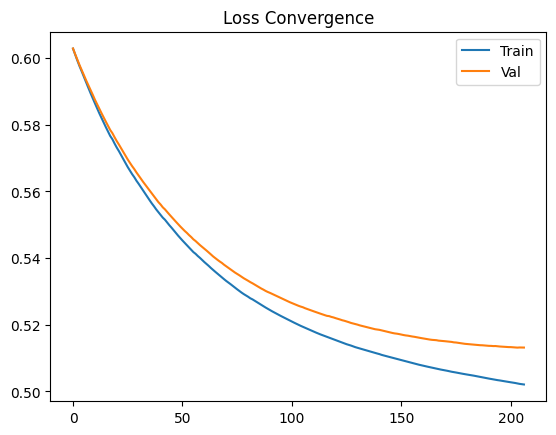

Stopped at iteration: 203
[2026-07-08 10:05:09.482140] ✅ XGBoost saved to: /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/xgb_model.pkl


In [ ]:

# ============================================================
# Train XGBoost
# ============================================================
print(f"\n[{datetime.now()}] 🚀 Training XGBoost...")

# neg = (y_train_snap == 0).sum()
# pos = (y_train_snap == 1).sum()
# XGB_scale_pos_weight = neg / pos
# print(f"   Class ratio → Normal: {neg}, Fraud: {pos}, scale_pos_weight: {XGB_scale_pos_weight:.2f}")

# Already computed above for XGB, reuse the same neg/pos
#RF_class_weight = {
#    0: 1.0,           # normal users — keep as 1
#    1: neg / pos      # fraud users — same ratio as XGB
#}
#print(f"   RF class_weight: {RF_class_weight}")


xgb_model = XGBClassifier(
    n_estimators=xgb_parameters["n_estimators"],
    learning_rate=xgb_parameters["learning_rate"] ,
    max_depth=xgb_parameters["max_depth"],
    subsample=xgb_parameters["subsample"],
    colsample_bytree=xgb_parameters["colsample_bytree"],
    min_child_weight=xgb_parameters["min_child_weight"],
    gamma=xgb_parameters["gamma"],
    eval_metric=xgb_parameters["eval_metric"],
    random_state=42,
    early_stopping_rounds=xgb_parameters["patience"],
    n_jobs=-1,
    verbose=1
    )
xgb_model.fit(X_train_scaled, y_train_snap, eval_set=[(X_train_scaled, y_train_snap), (X_val_scaled, y_val_snap)], verbose=True)
results = xgb_model.evals_result()
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Val')
plt.legend()
plt.title("Loss Convergence")
plt.show()

print(f"Stopped at iteration: {xgb_model.best_iteration}") # POINT 4 Check

xgb_save_path = os.path.join(model_path, "xgb_model.pkl")
joblib.dump(xgb_model, xgb_save_path)
print(f"[{datetime.now()}] ✅ XGBoost saved to: {xgb_save_path}")


## Random Forest

In [ ]:

# ============================================================
# Train Random Forest
# ============================================================
print(f"\n[{datetime.now()}] 🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=rf_parameters["n_estimators"],
    max_depth=rf_parameters["max_depth"],
    min_samples_split = rf_parameters["min_samples_split"],
    min_samples_leaf = rf_parameters["min_samples_leaf"],
    random_state=42,
    n_jobs=-1,
    verbose=0,
    oob_score=True

)
rf_model.fit(X_train_scaled, y_train_snap)
oob_f1 = rf_model.oob_score_
train_f1 = f1_score(y_train_snap, rf_model.predict(X_train_scaled), zero_division=0)
rf_save_path = os.path.join(model_path, "rf_model.pkl")
joblib.dump(rf_model, rf_save_path)
print(f"[{datetime.now()}] ✅ Random Forest saved to: {rf_save_path}")


print(f"RF Internal Gap (Train - OOB): {round(train_f1 - oob_f1, 4)}")

# # (Assumes you still have xgb_val_probs and best_thr from earlier)
#rf_val_probs = rf_model.predict_proba(X_val_scaled)[:, 1]

# xgb_preds = (xgb_val_probs >= best_thr).astype(int)
# rf_preds = (rf_val_probs >= best_thr_rf).astype(int)

# kappa = cohen_kappa_score(xgb_preds, rf_preds)
# print(f"🤝 Model Agreement (Kappa): {kappa:.4f}")


[2026-07-08 10:05:09.489057] 🌲 Training Random Forest...
[2026-07-08 10:05:11.557657] ✅ Random Forest saved to: /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/rf_model.pkl
RF Internal Gap (Train - OOB): -0.1955


## Full Evaluation

#### XGB

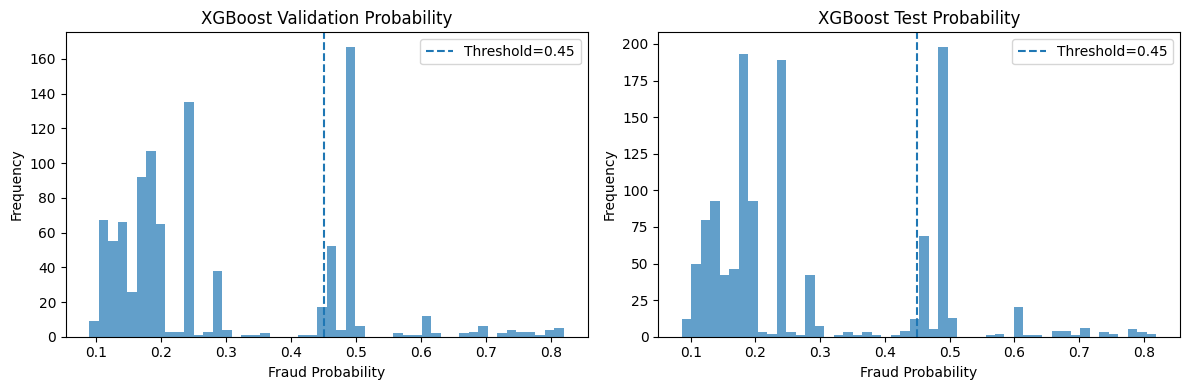


📊 XGBoost Confusion Matrix


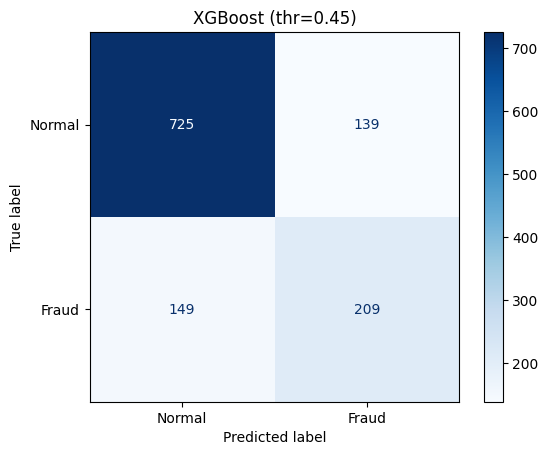


📊 Detailed Report: XGBoost
              precision    recall  f1-score   support

      Normal     0.8295    0.8391    0.8343       864
       Fraud     0.6006    0.5838    0.5921       358

    accuracy                         0.7643      1222
   macro avg     0.7150    0.7115    0.7132      1222
weighted avg     0.7624    0.7643    0.7633      1222



In [ ]:

# Select thresholds on validation only
y_pred_val_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
best_thr_xgb_val, best_f1_xgb_val = find_best_threshold(y_val_snap, y_pred_val_xgb)

# ============================================================
# XGBoost Gap Evaluation
# ============================================================

xgb_train_probs = xgb_model.predict_proba(X_train_scaled)[:, 1]
xgb_val_probs   = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_test_probs  = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_train_f1 = f1_score(y_train_snap, (xgb_train_probs >= best_thr_xgb_val).astype(int), zero_division=0)
xgb_val_f1   = f1_score(y_val_snap,   (xgb_val_probs   >= best_thr_xgb_val).astype(int), zero_division=0)
xgb_test_f1  = f1_score(y_test_snap,  (xgb_test_probs  >= best_thr_xgb_val).astype(int), zero_division=0)

gap_table = append_gap_result(
    gap_table,
    "XGBoost",
    xgb_train_f1,
    xgb_val_f1,
    xgb_test_f1,
    best_thr_xgb_val
)

plot_probability_distribution(
    "XGBoost",
    xgb_val_probs,
    xgb_test_probs,
    best_thr_xgb_val
)
# -----------------------------
# XGBoost — use validation-selected threshold
# -----------------------------
y_pred_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
best_thr_xgb = best_thr_xgb_val
y_pred_xgb_bin = (y_pred_xgb >= best_thr_xgb).astype(int)
best_f1_xgb = f1_score(y_test_snap, y_pred_xgb_bin, zero_division=0)

xgb_results = {
    "NAS SL": Base_SL,
    "Testing SL": max_seq_len,
    "f1": best_f1_xgb,
    "auc": roc_auc_score(y_test_snap, y_pred_xgb),
    "recall": recall_score(y_test_snap, y_pred_xgb_bin, zero_division=0),
    "precision": precision_score(y_test_snap, y_pred_xgb_bin, zero_division=0),
    "threshold": best_thr_xgb
}
summary = append_to_summary(summary, "XGBoost", xgb_results)
# ------------------------------------------------------------
# Confusion Matrices
# ------------------------------------------------------------
print("\n📊 XGBoost Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    y_test_snap,
    y_pred_xgb_bin,
    display_labels=["Normal", "Fraud"],
    cmap="Blues"
)
plt.title(f"XGBoost (thr={best_thr_xgb:.2f})")
plt.show()
print_detailed_report("XGBoost", y_test_snap, y_pred_xgb_bin)

#### Random Forest

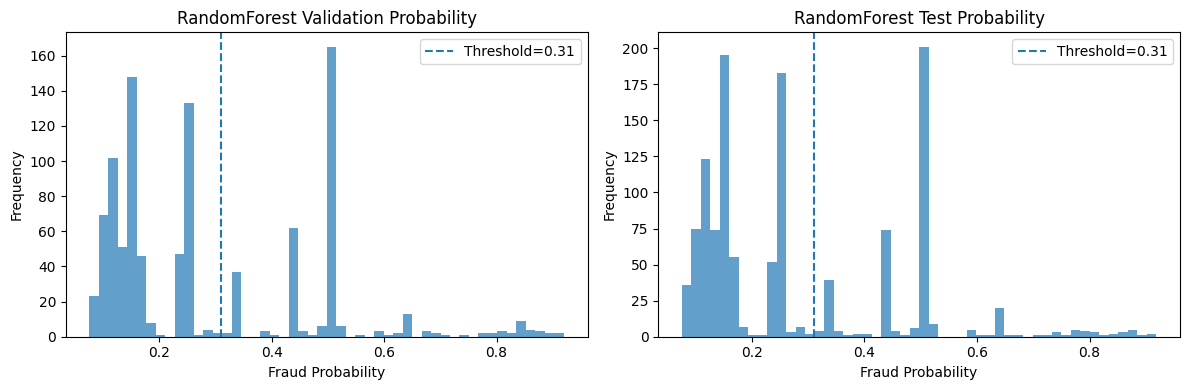


📊 Random Forest Confusion Matrix


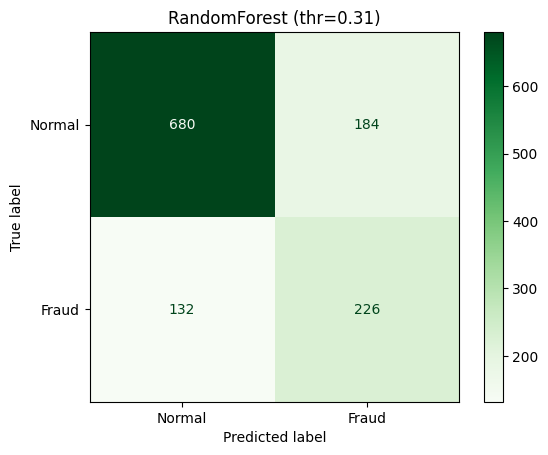


📊 Detailed Report: RandomForest
              precision    recall  f1-score   support

      Normal     0.8374    0.7870    0.8115       864
       Fraud     0.5512    0.6313    0.5885       358

    accuracy                         0.7414      1222
   macro avg     0.6943    0.7092    0.7000      1222
weighted avg     0.7536    0.7414    0.7462      1222



In [ ]:

y_pred_val_rf = rf_model.predict_proba(X_val_scaled)[:, 1]
best_thr_rf_val, best_f1_rf_val = find_best_threshold(y_val_snap, y_pred_val_rf)
# ============================================================
# Random Forest Gap Evaluation
# ============================================================

rf_train_probs = rf_model.predict_proba(X_train_scaled)[:, 1]
rf_val_probs   = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_test_probs  = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_train_f1 = f1_score(y_train_snap, (rf_train_probs >= best_thr_rf_val).astype(int), zero_division=0)
rf_val_f1   = f1_score(y_val_snap,   (rf_val_probs   >= best_thr_rf_val).astype(int), zero_division=0)
rf_test_f1  = f1_score(y_test_snap,  (rf_test_probs  >= best_thr_rf_val).astype(int), zero_division=0)

gap_table = append_gap_result(
    gap_table,
    "RandomForest",
    rf_train_f1,
    rf_val_f1,
    rf_test_f1,
    best_thr_rf_val
)

plot_probability_distribution(
    "RandomForest",
    rf_val_probs,
    rf_test_probs,
    best_thr_rf_val
)


# -----------------------------
# Random Forest — use validation-selected threshold
# -----------------------------
y_pred_rf = rf_test_probs
best_thr_rf = best_thr_rf_val
y_pred_rf_bin = (y_pred_rf >= best_thr_rf).astype(int)
best_f1_rf = f1_score(y_test_snap, y_pred_rf_bin, zero_division=0)

rf_results = {
    "NAS SL": Base_SL,
    "Testing SL": max_seq_len,
    "f1": best_f1_rf,
    "auc": roc_auc_score(y_test_snap, y_pred_rf),
    "recall": recall_score(y_test_snap, y_pred_rf_bin, zero_division=0),
    "precision": precision_score(y_test_snap, y_pred_rf_bin, zero_division=0),
    "threshold": best_thr_rf
}
summary = append_to_summary(summary, "RandomForest", rf_results)


# ------------------------------------------------------------
# Confusion Matrices
# ------------------------------------------------------------
print("\n📊 Random Forest Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    y_test_snap,
    y_pred_rf_bin,
    display_labels=["Normal", "Fraud"],
    cmap="Greens"
)
plt.title(f"RandomForest (thr={best_thr_rf:.2f})")
plt.show()
print_detailed_report("RandomForest", y_test_snap, y_pred_rf_bin)



#### show

XGBoost feature importance


,Feature,Importance
2,f2,46.557476
10,f10,31.372869
4,f4,19.289150
12,f12,13.136675
16,f16,12.990861
18,f18,11.474965
0,f0,10.097383
8,f8,9.857931
3,f3,8.361500
9,f9,8.358512


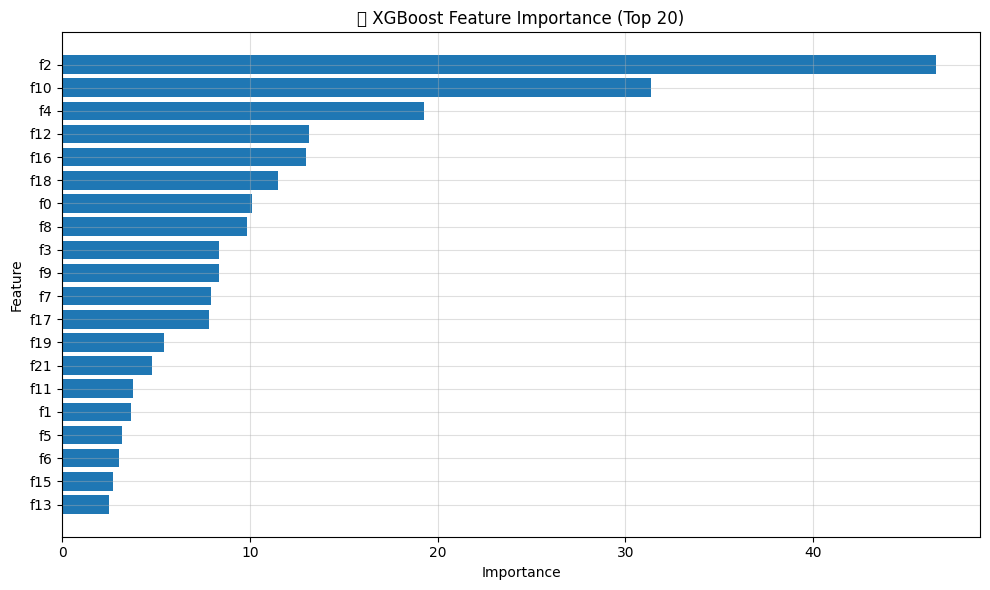

Random Forest feature importance


,Feature,Importance
10,sms_active_hours,0.155320
4,voc_max_duration,0.121629
2,voc_total_duration,0.097610
3,voc_avg_duration,0.082841
9,sms_unique_contacts,0.067113
6,voc_active_days,0.059396
19,arpu_mean,0.045342
21,arpu_max,0.041158
7,voc_active_hours,0.040632
17,app_unique_apps_max,0.036115


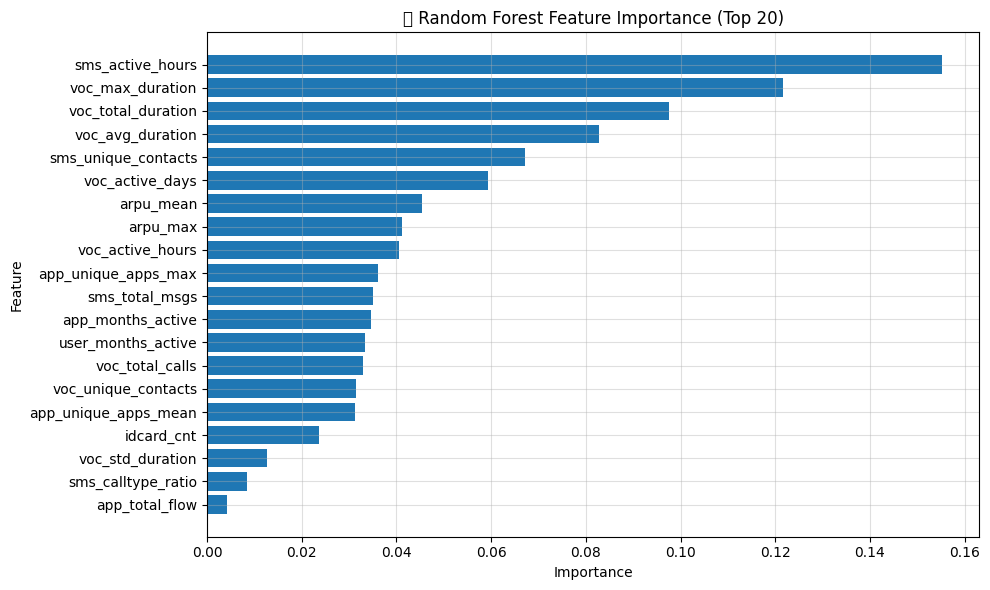

Summary


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31


Gap


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,RandomForest,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
1,XGBoost,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


In [ ]:
print("XGBoost feature importance")
fi_xgb = plot_feature_importance(xgb_model, pd.DataFrame(
    X_train_scaled,
    columns=X_train_snap.columns,
    index=X_train_snap.index
)
, "XGBoost")
print("Random Forest feature importance")

fi_rf = plot_feature_importance(rf_model, pd.DataFrame(
    X_train_scaled,
    columns=X_train_snap.columns,
    index=X_train_snap.index
), "Random Forest")

print("Summary")
display(summary)

print("Gap")
display(gap_table.sort_values("Model").reset_index(drop=True))

### Progressive Evaluation

In [ ]:

# ============================================================
# Progressive Evaluation
# ============================================================
print("\n" + "="*60)
print(f"[{datetime.now()}] 🔄 Progressive Evaluation (RF/XGBoost)")
print("="*60)
print(f"📊 Key rounds: {key_rounds}")

for r in key_rounds:
    print(f"\n[{datetime.now()}] [RF/XGB] Round {r}/{max_seq_len} - generating snapshots...")

    X_r, y_r, users_r = generate_snapshots_from_events(
        events_df=test_events_unscaled,
        users=test_users,
        r=r,
        max_seq_len=max_seq_len,
        recent_mode=recent_mode
    )
    print(f"[{datetime.now()}] ✅ Snapshots generated for round {r}")

    if len(X_r) == 0:
        print(f"[{datetime.now()}] ⚠️ No data for round {r}, skipping...")
        continue

    X_r = X_r.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
    X_r_scaled = scaler_snap.transform(X_r)

    # XGBoost — threshold sweep
    y_pred_xgb = xgb_model.predict_proba(X_r_scaled)[:, 1]
    y_pred_xgb_bin = (y_pred_xgb >= best_thr_xgb_val).astype(int)
    auc_xgb = roc_auc_score(y_r, y_pred_xgb)

    rec_xgb = recall_score(y_r, y_pred_xgb_bin, zero_division=0)
    prec_xgb = precision_score(y_r, y_pred_xgb_bin, zero_division=0)
    f1_xgb = f1_score(y_r, y_pred_xgb_bin, zero_division=0)
    thr_xgb = best_thr_xgb_val

    # Random Forest — threshold sweep
    y_pred_rf = rf_model.predict_proba(X_r_scaled)[:, 1]
    y_pred_rf_bin = (y_pred_rf >= best_thr_rf_val).astype(int)
    auc_rf = roc_auc_score(y_r, y_pred_rf)

    rec_rf = recall_score(y_r, y_pred_rf_bin, zero_division=0)
    prec_rf = precision_score(y_r, y_pred_rf_bin, zero_division=0)
    f1_rf = f1_score(y_r, y_pred_rf_bin, zero_division=0)
    thr_rf = best_thr_rf_val

    results_table = pd.concat([
        results_table,
        pd.DataFrame([
            {
                "NAS SL": Base_SL,
                "Testing SL": max_seq_len,
                "Round": r,
                "Model": "XGBoost",
                "AUC": auc_xgb,
                "Recall": rec_xgb,
                "Precision": prec_xgb,
                "F1": f1_xgb,
                "threshold": thr_xgb,
                },
              {
                  "NAS SL": Base_SL,
                  "Testing SL": max_seq_len,
                  "Round": r,
                  "Model": "RandomForest",
                  "AUC": auc_rf,
                  "Recall": rec_rf,
                  "Precision": prec_rf,
                  "F1": f1_rf,
                  "threshold": thr_rf,
                  },
          ])
      ], ignore_index=True)

    print(
        f"[{datetime.now()}] "
        f"XGB: AUC={auc_xgb:.4f}, P={prec_xgb:.4f}, R={rec_xgb:.4f}, F1={f1_xgb:.4f}, thr={thr_xgb:.2f} | "
        f"RF: AUC={auc_rf:.4f}, P={prec_rf:.4f}, R={rec_rf:.4f}, F1={f1_rf:.4f}, thr={thr_rf:.2f}"
        )

print(f"\n[{datetime.now()}] ✅ RF/XGBoost progressive evaluation complete")
display(results_table[results_table["Model"].isin(["XGBoost", "RandomForest"])])


[2026-07-08 10:05:14.359470] 🔄 Progressive Evaluation (RF/XGBoost)
📊 Key rounds: [1, 2, 3, 4]

[2026-07-08 10:05:14.360104] [RF/XGB] Round 1/4 - generating snapshots...


Generating snapshots: 100%|██████████| 1222/1222 [00:03<00:00, 327.04it/s]


[2026-07-08 10:05:22.881051] ✅ Snapshots generated for round 1
[2026-07-08 10:05:22.962309] XGB: AUC=0.6639, P=0.3689, R=0.8603, F1=0.5163, thr=0.45 | RF: AUC=0.6539, P=0.3694, R=0.8771, F1=0.5199, thr=0.31

[2026-07-08 10:05:22.962404] [RF/XGB] Round 2/4 - generating snapshots...


Generating snapshots: 100%|██████████| 1222/1222 [00:03<00:00, 347.60it/s]


[2026-07-08 10:05:31.257615] ✅ Snapshots generated for round 2
[2026-07-08 10:05:31.350264] XGB: AUC=0.7012, P=0.3884, R=0.8212, F1=0.5274, thr=0.45 | RF: AUC=0.7024, P=0.3903, R=0.8296, F1=0.5308, thr=0.31

[2026-07-08 10:05:31.350374] [RF/XGB] Round 3/4 - generating snapshots...


Generating snapshots: 100%|██████████| 1222/1222 [00:03<00:00, 343.07it/s]


[2026-07-08 10:05:40.207903] ✅ Snapshots generated for round 3
[2026-07-08 10:05:40.288168] XGB: AUC=0.7294, P=0.4157, R=0.7989, F1=0.5468, thr=0.45 | RF: AUC=0.7285, P=0.4085, R=0.8296, F1=0.5475, thr=0.31

[2026-07-08 10:05:40.288271] [RF/XGB] Round 4/4 - generating snapshots...


Generating snapshots: 100%|██████████| 1222/1222 [00:03<00:00, 325.11it/s]


[2026-07-08 10:05:48.848040] ✅ Snapshots generated for round 4
[2026-07-08 10:05:48.944550] XGB: AUC=0.7610, P=0.6006, R=0.5838, F1=0.5921, thr=0.45 | RF: AUC=0.7593, P=0.5512, R=0.6313, F1=0.5885, thr=0.31

[2026-07-08 10:05:48.944803] ✅ RF/XGBoost progressive evaluation complete


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round
0,4M,4,XGBoost,0.516345,0.663948,0.860335,0.368862,0.45,1
1,4M,4,RandomForest,0.519868,0.653908,0.877095,0.369412,0.31,1
2,4M,4,XGBoost,0.527354,0.701187,0.821229,0.388375,0.45,2
3,4M,4,RandomForest,0.530831,0.702360,0.829609,0.390276,0.31,2
4,4M,4,XGBoost,0.546845,0.729356,0.798883,0.415698,0.45,3
5,4M,4,RandomForest,0.547465,0.728462,0.829609,0.408528,0.31,3
6,4M,4,XGBoost,0.592068,0.760991,0.583799,0.600575,0.45,4
7,4M,4,RandomForest,0.588542,0.759303,0.631285,0.551220,0.31,4


# ▶  Advance ML

### Scale for DL

In [ ]:

#Scale
#scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label"})
scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label", "source_id"})
scaler_seq = StandardScaler().fit(train_events[scale_cols_seq])
#Training data only to be used for calc the scaler
train_events[scale_cols_seq] = scaler_seq.transform(train_events[scale_cols_seq])
test_events[scale_cols_seq]  = scaler_seq.transform(test_events[scale_cols_seq])
val_events[scale_cols_seq]   = scaler_seq.transform(val_events[scale_cols_seq])

# ======================================
# Create Sequences (using multiple features)
# ======================================
numeric_features = [c for c in numeric_cols if c not in ["label"]]  # exclude label

#add dt_hours
if 'dt_hours' in train_events.columns:
    numeric_features.append('dt_hours')

print(f"\n📦 Features used for sequences: {numeric_features}")
feature_cols_tf = numeric_features.copy()

#add source_id
if "source_id" not in feature_cols_tf:
    feature_cols_tf.append("source_id")

print("[Transformer] feature_cols_tf:", feature_cols_tf)


📦 Features used for sequences: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours']
[Transformer] feature_cols_tf: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours', 'source_id']


### make_user_sequences

In [ ]:

# ============================================================
# 2️⃣ Selector functions (FIXED, SIMPLE)
# ============================================================

def selector_oldest(r):
    """Select oldest r events"""
    return lambda df_u: df_u.head(r)

# def selector_last_r(r):
#     """Select LAST r events (to match full evaluation behavior)"""
#     return lambda df_u: df_u.tail(r)

# def selector_most_recent(r):
#     """Select most recent r events (used AFTER window freeze)"""
#     return lambda df_u: df_u.tail(r)

def make_user_sequences(
    events,
    feature_cols=None,
    max_seq_len=100,
    event_selector=None,
):
    events = events.copy()
    users, X_seq, y = [], [], []

    # le = LabelEncoder()
    # events["source_id"] = le.fit_transform(events["source"].astype(str))
    SOURCE_MAP = {
        "APP": 0,
        "SMS": 1,
        "USER": 2,
        "VOC": 3,
    }

    unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
    assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"

    events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]) \
                             .columns.difference(["label"]) \
                             .tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):

        # 1️⃣ Sort
        df_u = df_u.sort_values("event_time")

        # 2️⃣ Freeze to last max_seq_len
        if recent_mode:
            df_u = df_u.tail(max_seq_len)   # E51..E100

        # 3️⃣ 🔁 APPLY PROGRESSIVE SELECTION HERE
        if event_selector is not None:
            df_u = event_selector(df_u)

        # 4️⃣ Features
        feats = df_u[feature_cols].to_numpy(dtype=float)

        # 5️⃣ Pad / truncate
        if len(feats) < max_seq_len:
            feats = np.pad(feats, ((max_seq_len - len(feats), 0), (0, 0)))
        else:
            feats = feats[-max_seq_len:]

        label = int(df_u["label"].max())

        X_seq.append(feats)
        y.append(label)
        users.append(user)

    return np.array(X_seq), np.array(y), np.array(users)



### Create sequences

In [ ]:

trans_X_train, trans_y_train, users_train = make_user_sequences(train_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=event_selector=selector_oldest(max_seq_len))
trans_X_test, trans_y_test, users_test = make_user_sequences(test_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=event_selector=selector_oldest(max_seq_len))
trans_X_val, trans_y_val, _ =            make_user_sequences(val_events,    feature_cols=numeric_features,max_seq_len=max_seq_len, event_selector=event_selector=selector_oldest(max_seq_len))
assert len(set(val_events["phone_no_m"])) > 0, "❌ Validation set is empty!"
assert val_events["label"].nunique() == 2, "❌ Validation set must contain both classes"

print("\n✅ Sequence Summary (per-user sequences):")
print(f"   X_train: {trans_X_train.shape} | Fraud ratio: {np.mean(trans_y_train)*100:.2f}%")
print(f"   X_test : {trans_X_test.shape} | Fraud ratio: {np.mean(trans_y_test)*100:.2f}%")

# ======================================
# Consistency Check
# ======================================
trans_rf_train = set(pd.read_csv(train_split_file)["phone_no_m"])
trans_rf_test  = set(pd.read_csv(test_split_file)["phone_no_m"])
assert trans_rf_train == train_users, "❌ Train user mismatch between LSTM and RF/XGB!"
assert trans_rf_test  == test_users,  "❌ Test user mismatch between LSTM and RF/XGB!"
print("\n🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).")



✅ Sequence Summary (per-user sequences):
   X_train: (3907, 4, 8) | Fraud ratio: 29.28%
   X_test : (1222, 4, 8) | Fraud ratio: 29.30%

🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).


### Correlation raw data

📊 Correlation Matrix — Raw Event Features (LSTM)


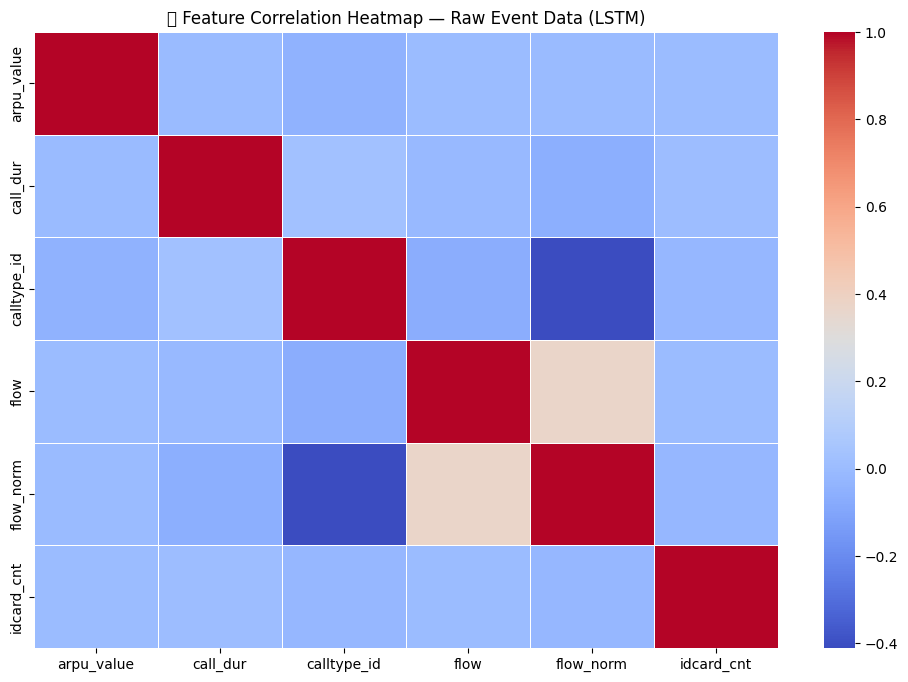

,Feature1,Feature2,Correlation


In [ ]:
# --- LSTM correlation ---
print("📊 Correlation Matrix — Raw Event Features (LSTM)")

corr_lstm = pd.DataFrame(events[numeric_cols]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_lstm, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("📊 Feature Correlation Heatmap — Raw Event Data (LSTM)")
plt.show()

# Optional: Highly correlated pairs

corr_pairs_lstm = (
    corr_lstm.where(np.triu(np.ones(corr_lstm.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs_lstm.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_lstm = corr_pairs_lstm[corr_pairs_lstm["Correlation"].abs() > correlation_threshold]
display(high_corr_lstm)


## ▶ LSTM



### Class_weights

In [ ]:
# weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(trans_y_train),
#     y=trans_y_train
# )
# class_weights = dict(enumerate(weights))
# print(class_weights)

### Model

In [ ]:
# ============================================================
# 📦 LSTM Model in PyTorch
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class LSTMFraud(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, n_layers=4, d_ff=128, dropout=0.393, num_classes=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        # Classification head (match TimesNet structure)
        self.cls = nn.Sequential(
            nn.Linear(hidden_dim, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, num_classes)  # d_ff -> 2 classes
        )

    def forward(self, x, mask=None):

        # LSTM forward
        lstm_out, (h_n, c_n) = self.lstm(x)
        out = h_n[-1]

        # If mask provided, use masked mean pooling instead
        if mask is not None:
            # mask: (batch, seq_len) - True where padded
            keep = (~mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
            denom = keep.sum(dim=1).clamp(min=1)  # (batch, 1)
            out = (lstm_out * keep).sum(dim=1) / denom  # (batch, hidden_dim)

        # Classification
        logits = self.cls(out)
        return logits


# ============================================================
# 🏗️ Instantiate Model
# ============================================================

lstm_model = LSTMFraud(
    input_dim=trans_X_train.shape[2],  # Number of features
    hidden_dim=lstm_parameters["d_model"],
    n_layers=lstm_parameters["e_layers"],
    d_ff=lstm_parameters["d_ff"],
    dropout=lstm_parameters["dropout"],
    num_classes=2
).to(device)

#print(lstm_model)

# ============================================================
# ⚙️ Optimizer & Loss
# ============================================================

optimizer = torch.optim.RAdam(lstm_model.parameters(), lr=lstm_parameters["learning_rate"])  # ✅ RAdam!
criterion = nn.CrossEntropyLoss()  # ✅ No class weights



Using device: cuda


###  Data preparation

In [ ]:

# ============================================================
# 🔧 Prepare Data for PyTorch LSTM
# ============================================================
best_val_f1_lstm = -1.0
best_thr_lstm = 0.5
best_epoch_lstm = 0
patience_counter_lstm = 0


# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(trans_X_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(trans_X_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(trans_X_test, dtype=torch.float32).to(device)

y_train_t = torch.tensor(trans_y_train, dtype=torch.long).to(device)
y_val_t = torch.tensor(trans_y_val, dtype=torch.long).to(device)
y_test_t = torch.tensor(trans_y_test, dtype=torch.long).to(device)

# Create masks (True where padded - all zeros)
def create_padding_mask(X):
    # Assume padding is all zeros
    return (X.sum(dim=-1) == 0)  # (batch, seq_len)

#padding
M_train = create_padding_mask(X_train_t)
M_val = create_padding_mask(X_val_t)
M_test = create_padding_mask(X_test_t)

# DataLoaders
train_ds = TensorDataset(X_train_t, M_train, y_train_t)
val_ds = TensorDataset(X_val_t, M_val, y_val_t)
test_ds = TensorDataset(X_test_t, M_test, y_test_t)

# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
# test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

train_loader = DataLoader(train_ds, batch_size=lstm_parameters["batch_size"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=lstm_parameters["batch_size"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=lstm_parameters["batch_size"], shuffle=False)

#for comparing
train_eval_loader = DataLoader(
    train_ds,
    batch_size=lstm_parameters["batch_size"],
    shuffle=False
)

### Training and Validation

In [ ]:


# ============================================================
# 🚀 Training Loop
# ============================================================
lstm_train_losses = []
lstm_val_losses = []
lstm_val_f1s = []

print("\n🚀 Training LSTM (PyTorch)...")

for ep in range(1, epochs + 1):
    # -------- TRAIN --------
    lstm_model.train()
    loss_sum = 0.0

    for xb, mb, yb in train_loader:
        logits = lstm_model(xb, mask=mb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping (match TimesNet max_norm=4.0)
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=4.0)

        optimizer.step()
        loss_sum += loss.item() * len(xb)

    train_loss = loss_sum / len(train_ds)

    # -------- VALIDATION --------
    lstm_model.eval()
    val_loss_sum = 0.0  # Initialize sum for val loss tracking
    all_val_probs, all_val_labels = [], []

    with torch.no_grad():
        for xb, mb, yb in val_loader:
            # Calculate logits and loss for the validation batch
            logits = lstm_model(xb, mask=mb)
            v_loss = criterion(logits, yb)
            val_loss_sum += v_loss.item() * len(xb)

            # Get probabilities for F1 calculation
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_val_probs.extend(probs.cpu().numpy())
            all_val_labels.extend(yb.cpu().numpy())

    all_val_probs = np.array(all_val_probs)
    val_loss = val_loss_sum / len(val_ds)
    best_val_f1_epoch = -1.0
    best_thr_epoch = 0.5

    for thr in np.linspace(0.2, 0.8, 61):
        f1 = f1_score(all_val_labels, (all_val_probs >= thr).astype(int), zero_division=0)
        if f1 > best_val_f1_epoch:
            best_val_f1_epoch = f1
            best_thr_epoch = thr



        # Early stopping on val F1
    if best_val_f1_epoch > best_val_f1_lstm:
        best_val_f1_lstm = best_val_f1_epoch
        best_thr_lstm = best_thr_epoch
        best_epoch_lstm = ep
        patience_counter_lstm = 0
        torch.save(lstm_model.state_dict(), 'best_lstm.pt')
    else:
        patience_counter_lstm += 1
        if patience_counter_lstm >= lstm_parameters["patience"]:
            print(
                f"Early stopping at epoch {ep}/{epochs} | "
                f"best_epoch={best_epoch_lstm} | "
                f"best_val_f1={best_val_f1_lstm:.4f} | "
                f"best_thr={best_thr_lstm:.2f}"
            )
            break
    print(
        f"[LSTM] Epoch {ep:2d}/{epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_f1={best_val_f1_epoch:.4f} | "
        f"thr={best_thr_epoch:.2f} | "
        f"patience={patience_counter_lstm}/{lstm_parameters['patience']}"
    )
    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)
    lstm_val_f1s.append(best_val_f1_epoch)

print(f"✅ Best validation F1: {best_val_f1_lstm:.4f}")
print(f"✅ Best epoch: {best_epoch_lstm}")
print(f"✅ Best threshold: {best_thr_lstm:.2f}")

# Load best model
lstm_model.load_state_dict(torch.load('best_lstm.pt'))

# ============================================================
# 💾 Save Model
# ============================================================

lstm_save_path = os.path.join(model_path, "lstm_model_pytorch_state_dict.pt")
torch.save(lstm_model.state_dict(), lstm_save_path)
print(f"💾 LSTM state_dict saved to: {lstm_save_path}")




🚀 Training LSTM (PyTorch)...
[LSTM] Epoch  1/20 | train_loss=0.4851 | val_loss=0.3280 | val_f1=0.7835 | thr=0.35 | patience=0/3
[LSTM] Epoch  2/20 | train_loss=0.2814 | val_loss=0.2672 | val_f1=0.8556 | thr=0.27 | patience=0/3
[LSTM] Epoch  3/20 | train_loss=0.2673 | val_loss=0.3011 | val_f1=0.8493 | thr=0.59 | patience=1/3
[LSTM] Epoch  4/20 | train_loss=0.2671 | val_loss=0.2640 | val_f1=0.8620 | thr=0.61 | patience=0/3
[LSTM] Epoch  5/20 | train_loss=0.2645 | val_loss=0.2575 | val_f1=0.8507 | thr=0.33 | patience=1/3
[LSTM] Epoch  6/20 | train_loss=0.2647 | val_loss=0.2510 | val_f1=0.8615 | thr=0.42 | patience=2/3
Early stopping at epoch 7/20 | best_epoch=4 | best_val_f1=0.8620 | best_thr=0.61
✅ Best validation F1: 0.8620
✅ Best epoch: 4
✅ Best threshold: 0.61
💾 LSTM state_dict saved to: /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/lstm_model_pytorch_state_dict.pt


### Training stats

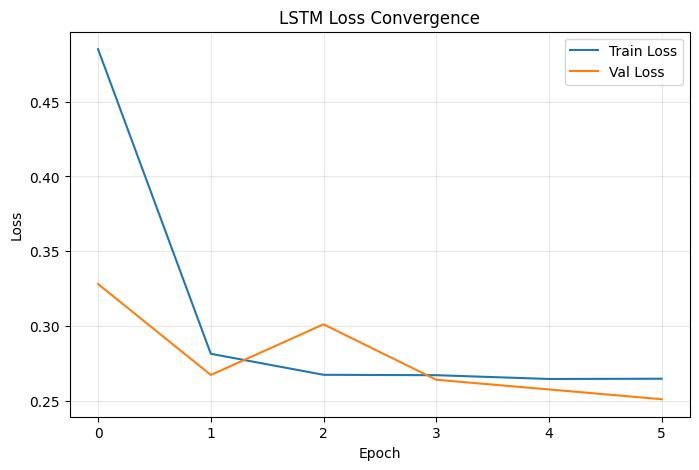

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(lstm_train_losses, label="Train Loss")
plt.plot(lstm_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Test Performance
lstm_model.eval()
all_test_probs = []
with torch.no_grad():
    for xb, mb, yb in test_loader:
        probs = torch.softmax(lstm_model(xb, mb), dim=1)[:, 1]
        all_test_probs.extend(probs.cpu().numpy())

all_test_probs = np.array(all_test_probs)
test_f1 = f1_score(y_test_t.cpu(), (all_test_probs >= best_thr_lstm).astype(int), zero_division=0)



##### Eval

###### Full

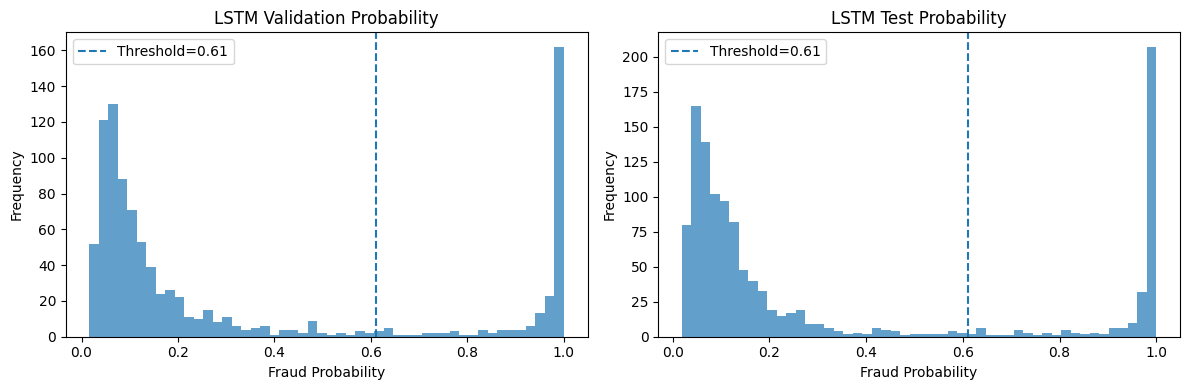


📊 LSTM Confusion Matrix


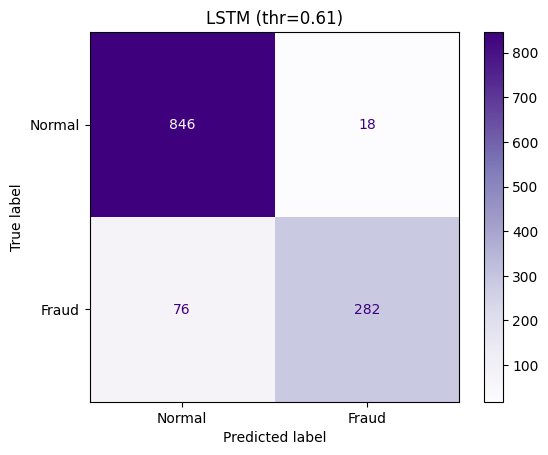


📊 Detailed Report: LSTM
              precision    recall  f1-score   support

      Normal     0.9176    0.9792    0.9474       864
       Fraud     0.9400    0.7877    0.8571       358

    accuracy                         0.9231      1222
   macro avg     0.9288    0.8834    0.9023      1222
weighted avg     0.9241    0.9231    0.9209      1222



,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
2,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61


In [ ]:
# ============================================================
# 📊 LSTM Evaluation (Full Test Set)
# ============================================================

lstm_model.eval()
preds_list = []

with torch.no_grad():
    for xb, mb, yb in test_loader:
        logits = lstm_model(xb, mask=mb)
        probs = torch.softmax(logits, dim=1)[:, 1]  # Probability of class 1
        preds_list.append(probs.cpu().numpy())

lstm_probs = np.concatenate(preds_list)
lstm_preds = (lstm_probs >= best_thr_lstm).astype(int)
best_f1_lstm_test = f1_score(trans_y_test, lstm_preds, zero_division=0)

# ============================================================
# LSTM Gap Evaluation
# ============================================================

def get_pytorch_probs(model, loader, device):
    model.eval()
    probs_list = []

    with torch.no_grad():
        for xb, mb, yb in loader:
            logits = model(xb, mask=mb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            probs_list.append(probs.cpu().numpy())

    return np.concatenate(probs_list)

lstm_train_probs = get_pytorch_probs(lstm_model, train_eval_loader, device)
lstm_val_probs   = get_pytorch_probs(lstm_model, val_loader, device)
lstm_test_probs  = get_pytorch_probs(lstm_model, test_loader, device)

lstm_train_f1 = f1_score(trans_y_train, (lstm_train_probs >= best_thr_lstm).astype(int), zero_division=0)
lstm_val_f1   = f1_score(trans_y_val,   (lstm_val_probs   >= best_thr_lstm).astype(int), zero_division=0)
lstm_test_f1  = f1_score(trans_y_test,  (lstm_test_probs  >= best_thr_lstm).astype(int), zero_division=0)

gap_table = append_gap_result(
    gap_table,
    "LSTM",
    lstm_train_f1,
    lstm_val_f1,
    lstm_test_f1,
    best_thr_lstm
)

plot_probability_distribution(
    "LSTM",
    lstm_val_probs,
    lstm_test_probs,
    best_thr_lstm
)

# Metrics
auc       = roc_auc_score(trans_y_test, lstm_probs)
recall    = recall_score(trans_y_test, lstm_preds, zero_division=0)
precision = precision_score(trans_y_test, lstm_preds, zero_division=0)
f1        = best_f1_lstm_test


# Add to summary
lstm_results = {
    "NAS SL": Base_SL,
    "Testing SL": max_seq_len,
    "f1":        f1,
    "auc":       auc,
    "precision": precision,
    "recall":    recall,
    "threshold": best_thr_lstm
}

summary = append_to_summary(summary, "LSTM", lstm_results)
# ============================================================
# 📊 LSTM Confusion Matrix
# ============================================================
print("\n📊 LSTM Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    trans_y_test,
    lstm_preds,
    display_labels=["Normal", "Fraud"],
    cmap="Purples"
)
plt.title(f"LSTM (thr={best_thr_lstm:.2f})")
plt.show()
print_detailed_report("LSTM", trans_y_test, lstm_preds)
display(summary)

###### Evaluate progressive

In [ ]:
# ============================================================
# 🔁 LSTM Progressive Evaluation
# ============================================================

def evaluate_lstm_progressive_pytorch(model, test_events, feature_cols, max_seq_len, recent_mode=False):
    """Progressive evaluation for PyTorch LSTM - ACTUAL FIX"""

    round_results = []
    print(f"\n🔁 [LSTM] Starting progressive evaluation (1..{max_seq_len} rounds)...")
    print(f"   recent_mode={recent_mode} (global)")

    for r in key_rounds:
        if r == max_seq_len:
            event_selector = None  # Full sequence, same as full evaluation
        else:
            event_selector = selector_oldest(r)  # Take LAST r events

        # Build sequences for this round
        X_r, y_r, users_r = make_user_sequences(
            test_events,
            feature_cols=feature_cols,
            max_seq_len=max_seq_len,
            event_selector=event_selector
        )

        # Convert to tensors
        X_r_t = torch.tensor(X_r, dtype=torch.float32).to(device)
        M_r = create_padding_mask(X_r_t)

        # Predict
        model.eval()
        with torch.no_grad():
            logits = model(X_r_t, mask=M_r)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = (probs >= best_thr_lstm).astype(int)


        # Metrics
        try:
            auc = roc_auc_score(y_r, probs)
        except:
            auc = 0.5

        recall = recall_score(y_r, preds, zero_division=0)
        precision = precision_score(y_r, preds, zero_division=0)
        f1 = f1_score(y_r, preds, zero_division=0)
        threshold = best_thr_lstm

        round_results.append({
            "NAS SL": Base_SL,
            "Testing SL": max_seq_len,
            "Model": "LSTM",
            "F1": f1,
            "AUC": auc,
            "Recall": recall,
            "Precision": precision,
            "threshold": threshold,
            "Round": r
        })

        print(f"   Round {r:2d} → AUC={auc:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f} | thr={threshold:.2f}")

    return pd.DataFrame(round_results)

# Run progressive evaluation
lstm_progressive_results = evaluate_lstm_progressive_pytorch(
    model=lstm_model,
    test_events=test_events,
    feature_cols=numeric_features,
    max_seq_len=max_seq_len,
    recent_mode=False
)

# Add to results table
results_table = results_table[results_table["Model"] != "LSTM"]
results_table = pd.concat([results_table, lstm_progressive_results], ignore_index=True)

display(lstm_progressive_results)

# Verification
print("\n" + "="*60)
print("🔍 VERIFICATION")
print("="*60)
round_full = lstm_progressive_results[lstm_progressive_results["Round"] == max_seq_len].iloc[0]
print(f"Progressive Round {max_seq_len} AUC: {round_full['AUC']:.4f}")
print(f"Full Evaluation AUC:      0.9210 (expected)")


🔁 [LSTM] Starting progressive evaluation (1..4 rounds)...
   recent_mode=False (global)
   Round  1 → AUC=0.7665 | Precision=0.8000 | Recall=0.0112 | F1=0.0220 | thr=0.61
   Round  2 → AUC=0.7796 | Precision=0.7931 | Recall=0.0642 | F1=0.1189 | thr=0.61
   Round  3 → AUC=0.7721 | Precision=0.7500 | Recall=0.0251 | F1=0.0486 | thr=0.61
   Round  4 → AUC=0.9162 | Precision=0.9400 | Recall=0.7877 | F1=0.8571 | thr=0.61


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round
0,4M,4,LSTM,0.022039,0.766467,0.011173,0.800000,0.61,1
1,4M,4,LSTM,0.118863,0.779616,0.064246,0.793103,0.61,2
2,4M,4,LSTM,0.048649,0.772149,0.025140,0.750000,0.61,3
3,4M,4,LSTM,0.857143,0.916191,0.787709,0.940000,0.61,4



🔍 VERIFICATION
Progressive Round 4 AUC: 0.9162
Full Evaluation AUC:      0.9210 (expected)


###### Show

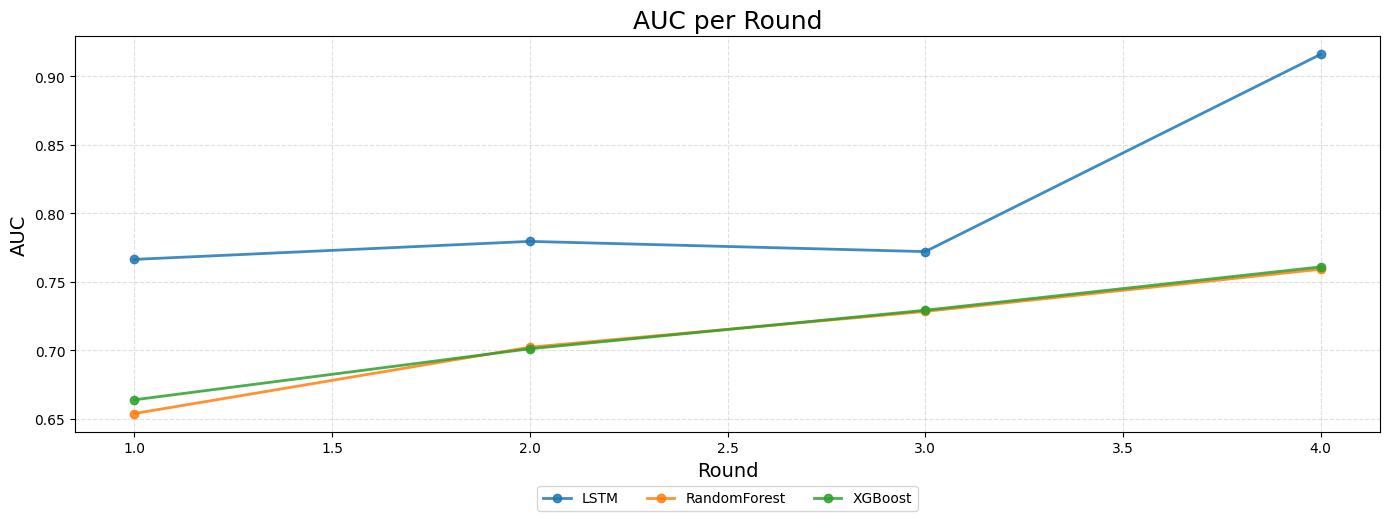

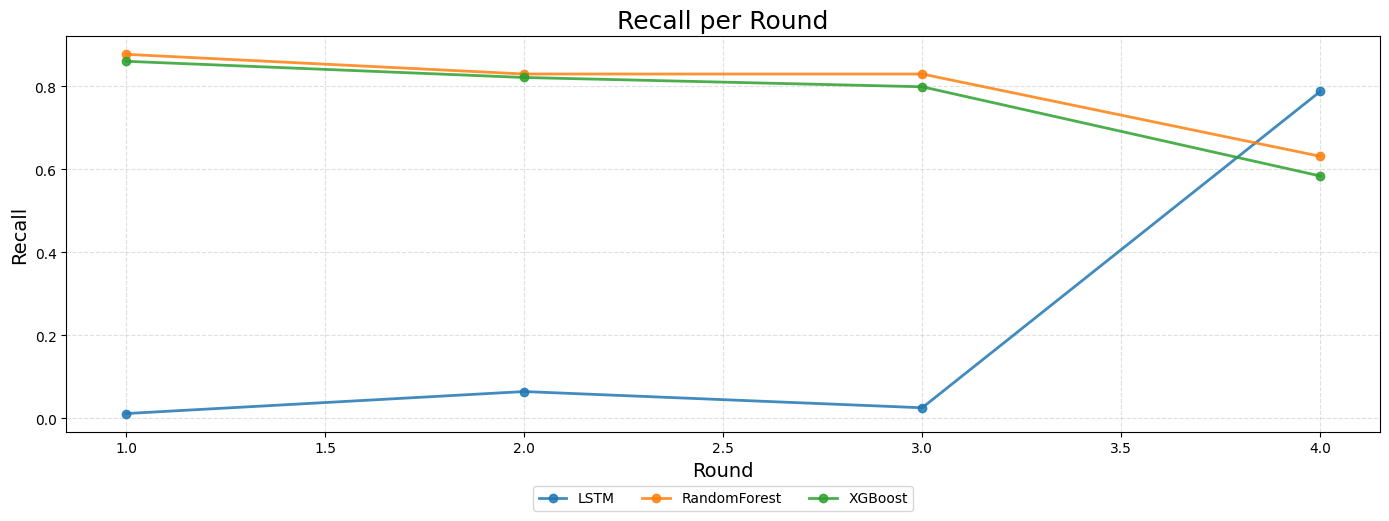

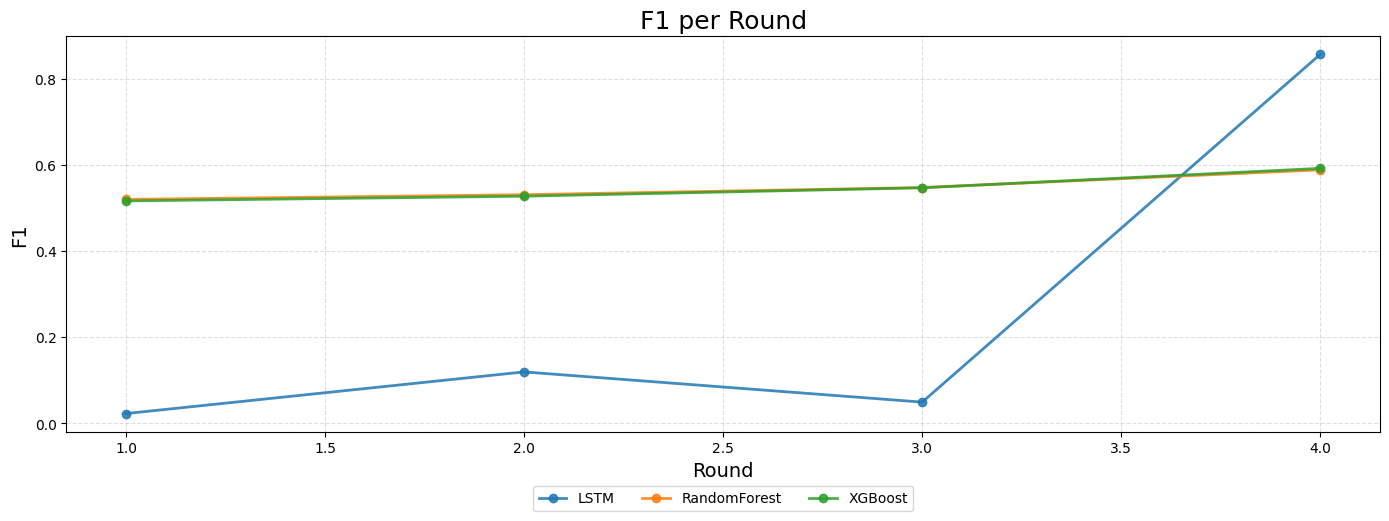

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round
0,4M,4,LSTM,0.022039,0.766467,0.011173,0.800000,0.61,1
1,4M,4,RandomForest,0.519868,0.653908,0.877095,0.369412,0.31,1
2,4M,4,XGBoost,0.516345,0.663948,0.860335,0.368862,0.45,1
3,4M,4,LSTM,0.118863,0.779616,0.064246,0.793103,0.61,2
4,4M,4,RandomForest,0.530831,0.702360,0.829609,0.390276,0.31,2
5,4M,4,XGBoost,0.527354,0.701187,0.821229,0.388375,0.45,2
6,4M,4,LSTM,0.048649,0.772149,0.025140,0.750000,0.61,3
7,4M,4,RandomForest,0.547465,0.728462,0.829609,0.408528,0.31,3
8,4M,4,XGBoost,0.546845,0.729356,0.798883,0.415698,0.45,3
9,4M,4,LSTM,0.857143,0.916191,0.787709,0.940000,0.61,4


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
2,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,LSTM,0.8437,0.8620,0.8571,-0.0183,-0.0135,0.0049,0.61
1,RandomForest,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
2,XGBoost,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


In [ ]:
plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col="Round"
)
display(summary)
display(gap_table.sort_values("Model").reset_index(drop=True))



## ▶ Transformer

#### Transformer Helper

In [ ]:
def build_tf_sequences_round(df_u, feature_cols, max_seq_len, r, recent_mode):
    """
    Builds a single user sequence for round r:
    - Apply recent/oldest window selection
    - Apply round selection (first r events inside window)
    - Left-pad to max_seq_len
    """

    df_u = df_u.sort_values("event_time")

    # Step 1: LSTM-identical window
    if recent_mode:
        df_u = df_u.iloc[-max_seq_len:]   # recent window
    else:
        df_u = df_u.iloc[:max_seq_len]    # oldest window

    # Step 2: now take only r events from the window
    df_u = df_u.head(r)

    # Extract features
    feats = df_u[feature_cols].to_numpy(dtype=float)
    dt_hours = df_u["dt_hours"].to_numpy(dtype=float).reshape(-1, 1)
    label = int(df_u["label"].max())

    L = len(feats)

    # Step 3: left-pad to max_seq_len
    if L < max_seq_len:
        pad_len = max_seq_len - L
        feats = np.pad(feats, ((pad_len, 0), (0, 0)))
        dt_hours = np.pad(dt_hours, ((pad_len, 0), (0, 0)))
        pad_mask = np.zeros((max_seq_len,), dtype=bool)
        pad_mask[:pad_len] = True
    else:
        feats = feats[-max_seq_len:]
        dt_hours = dt_hours[-max_seq_len:]
        pad_mask = np.zeros((max_seq_len,), dtype=bool)

    return feats, dt_hours, pad_mask, label

# ==============================================================
# NEW: Transformer helpers (no changes to existing LSTM path)
# ==============================================================


def build_tf_sequences(events, feature_cols=None, max_seq_len=100, recent_mode=False):
    """
    Build Transformer-ready sequences with:
      - X_seq:      [n_users, T, F]   numeric features
      - DT_seq:     [n_users, T, 1]   delta-time (hours) feature
      - PAD_mask:   [n_users, T]      True where PAD
      - y_user:     [n_users]         user labels
      - users:      list              phone_no_m
    NOTE: This is separate from make_user_sequences(); it does not replace it.
    """
    events = events.copy()
    users, X_seq, DT_seq, PAD_mask, y_user = [], [], [], [], []
    D_seq = []

    # Ensure numeric source_id exists (you already add it elsewhere)
    if "source_id" not in events.columns:


        SOURCE_MAP = {
            "APP": 0,
            "SMS": 1,
            "USER": 2,
            "VOC": 3,
        }
        unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
        assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"


        events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    # Default: all numeric except label
    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]).columns.difference(["label"]).tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):
        df_u = df_u.sort_values("event_time")
        # LSTM-identical logic:
        L = len(df_u)

        if recent_mode:
            # Step 1: take last max_seq_len events (recent window)
            df_u = df_u.iloc[-max_seq_len:]
        else:
            # Step 1: take oldest max_seq_len events
            df_u = df_u.iloc[:max_seq_len]


        dt_hours = df_u["dt_hours"].to_numpy(dtype=float).reshape(-1, 1)



        feats = df_u[feature_cols].to_numpy(dtype=float)
        L = len(feats)

        # Build padding mask: True where PAD (we left-pad to keep most recent)
        if L < max_seq_len:
            pad_len = max_seq_len - L
            feats   = np.pad(feats,   ((pad_len, 0), (0, 0)))
            dt_hours= np.pad(dt_hours,((pad_len, 0), (0, 0)))
            pad_mask = np.zeros((max_seq_len,), dtype=bool)
            pad_mask[:pad_len] = True
        else:
            feats = feats[-max_seq_len:]
            dt_hours = dt_hours[-max_seq_len:]
            pad_mask = np.zeros((max_seq_len,), dtype=bool)

        label = int(df_u["label"].max())

        X_seq.append(feats)
        DT_seq.append(dt_hours)
        PAD_mask.append(pad_mask)
        y_user.append(label)
        users.append(user)
        D_seq.append(df_u['dt_hours'].values[-max_seq_len:])



    X_seq   = np.stack(X_seq)
    DT_seq  = np.stack(DT_seq)
    PAD_mask= np.stack(PAD_mask)
    y_user  = np.array(y_user, dtype=int)
    return X_seq, DT_seq, PAD_mask, y_user, users, feature_cols

def evaluate_transformer_progressive(model, events, users, feature_cols, max_seq_len, recent_mode=False):
    """
    Progressive evaluation for Transformer - MEMORY EFFICIENT VERSION.
    Evaluates for r in key_rounds, processing users in batches to avoid OOM.
    """

    print(f"\n[Transformer] Starting progressive evaluation ({max_seq_len} rounds)...")
    print(f"[Transformer] Using feature columns: {feature_cols}")

    # --------------------------------------------------------
    # Ensure source_id is included (same as training)
    # --------------------------------------------------------
    events = events.copy()

    if "source_id" not in events.columns:
        print("[Transformer] Adding missing 'source_id' to events...")
        SOURCE_MAP = {"APP": 0, "SMS": 1, "USER": 2, "VOC": 3}
        events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    rounds = []
    aucs = []
    recalls = []
    precisions = []
    thresholds = []
    f1s = []

    # --------------------------------------------------------
    # Batch size for inference (adjust if still OOM)
    # --------------------------------------------------------
    INFERENCE_BATCH_SIZE = 16  # Process 64 users at a time

    # --------------------------------------------------------
    # Pre-group events by user (do this once, not per round)
    # --------------------------------------------------------
    user_groups = {user: df_u for user, df_u in events.groupby("phone_no_m") if user in users}
    user_list = list(user_groups.keys())
    print(f"[Transformer] Total users to evaluate: {len(user_list)}")

    # --------------------------------------------------------
    # Evaluate r in key_rounds
    # --------------------------------------------------------
    for r in key_rounds:

        print(f"[Transformer] Round {r}/{max_seq_len}...")

        all_preds = []
        all_labels = []

        # Process users in batches
        for batch_start in range(0, len(user_list), INFERENCE_BATCH_SIZE):
            batch_users = user_list[batch_start:batch_start + INFERENCE_BATCH_SIZE]

            X_list = []
            DT_list = []
            MASK_list = []
            y_list = []

            for user in batch_users:
                df_u = user_groups[user]

                try:
                    feats, dt_hours, pad_mask, label = build_tf_sequences_round(
                        df_u, feature_cols, max_seq_len, r, recent_mode
                    )
                except KeyError as e:
                    print(f"[ERROR] Missing column in df_u for user {user}: {e}")
                    continue

                # Scale features
                feats = scaler_tf.transform(
                    feats.reshape(-1, feats.shape[-1])
                ).reshape(feats.shape)

                X_list.append(feats)
                DT_list.append(dt_hours)
                MASK_list.append(pad_mask)
                y_list.append(label)

            if len(X_list) == 0:
                continue

            # Convert to arrays
            X_arr = np.stack(X_list)
            D_arr = np.stack(DT_list)
            M_arr = np.stack(MASK_list)

            # Tensors
            X_t = torch.tensor(X_arr, dtype=torch.float32, device=device)
            DT_t = torch.tensor(D_arr, dtype=torch.float32, device=device)
            MASK_t = torch.tensor(M_arr, dtype=torch.bool, device=device)

            # Forward pass
            model.eval()
            with torch.no_grad():
                #logits = model(X_t, DT_t, MASK_t)
                logits = model(X_t, pad_mask=MASK_t)
                probs = torch.softmax(logits, dim=1)[:, 1]
                batch_preds = probs.cpu().numpy()

            all_preds.extend(batch_preds)
            all_labels.extend(y_list)

            # ✅ Clear GPU memory after each batch
            del X_t, DT_t, MASK_t, logits, probs
            torch.cuda.empty_cache()

        # Compute metrics for this round
        if len(all_preds) == 0:
            print(f"[WARNING] No predictions for round {r}")
            continue

        y_arr = np.array(all_labels)
        preds = np.array(all_preds)

        try:
            auc = roc_auc_score(y_arr, preds)
        except:
            auc = 0.5

        p = (preds >= best_thr_tf).astype(int)

        f1 = f1_score(y_arr, p, zero_division=0)
        recall = recall_score(y_arr, p, zero_division=0)
        precision = precision_score(y_arr, p, zero_division=0)
        threshold = best_thr_tf

        rounds.append(r)
        aucs.append(auc)
        recalls.append(recall)
        precisions.append(precision)
        thresholds.append(threshold)
        f1s.append(f1)

        print(f"[Transformer] Round {r}: AUC={auc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, thr={threshold:.2f}")

    print("[Transformer] Progressive evaluation complete.")

    # Return results
    return pd.DataFrame({
      "NAS SL": Base_SL,
      "Testing SL": max_seq_len,
      "F1": f1s,
      "Round": rounds,
      "AUC": aucs,
      "Recall": recalls,
      "Precision": precisions,
      "threshold": thresholds
      })




####Scale, prepare  and select device

In [ ]:

print("\n🧪 [Transformer] Building sequences...")
max_seq_len_tf = max_seq_len

# Build Transformer-ready sequences (no leakage; uses your existing train/test splits)
Xtr_raw, DTr_raw, Mtr, ytr, users_tr, feature_cols_tf = build_tf_sequences(
    train_events_unscaled,
    max_seq_len=max_seq_len_tf
)
Xte_raw, DTe_raw, Mte, yte, users_te, _ = build_tf_sequences(
    test_events_unscaled,
    feature_cols=feature_cols_tf,  # <-- IMPORTANT
    max_seq_len=max_seq_len_tf
)

Xval_raw, DVal_raw, Mval, yval, users_val, _ = build_tf_sequences(
    val_events_unscaled,
    feature_cols=feature_cols_tf,
    max_seq_len=max_seq_len_tf
)



num_features = Xtr_raw.shape[2]

# Use mask: Mtr is True where PAD, so ~Mtr selects real rows
Xtr_real = Xtr_raw[~Mtr]   # shape: [num_real_rows, num_features]

scaler_tf = StandardScaler().fit(Xtr_real)

# Transform full tensors row-wise
Xtr = scaler_tf.transform(Xtr_raw.reshape(-1, num_features)).reshape(Xtr_raw.shape)
Xte = scaler_tf.transform(Xte_raw.reshape(-1, num_features)).reshape(Xte_raw.shape)
Xval = scaler_tf.transform(Xval_raw.reshape(-1, num_features)).reshape(Xval_raw.shape)

# Optional: force padded rows back to zero after scaling
Xtr[Mtr] = 0.0
Xte[Mte] = 0.0
Xval[Mval] = 0.0

# Convert to tensors



Xtr_t = torch.tensor(Xtr, dtype=torch.float32).to(device)
Xte_t = torch.tensor(Xte, dtype=torch.float32).to(device)
Xval_t = torch.tensor(Xval, dtype=torch.float32).to(device)

DTr_t = torch.tensor(DTr_raw, dtype=torch.float32).to(device)
DTe_t = torch.tensor(DTe_raw, dtype=torch.float32).to(device)
DVal_t = torch.tensor(DVal_raw, dtype=torch.float32).to(device)

Mtr_t = torch.tensor(Mtr, dtype=torch.bool).to(device)
Mte_t = torch.tensor(Mte, dtype=torch.bool).to(device)
Mval_t = torch.tensor(Mval, dtype=torch.bool).to(device)

ytr_t = torch.tensor(ytr, dtype=torch.long).to(device)
yte_t = torch.tensor(yte, dtype=torch.long).to(device)
yval_t = torch.tensor(yval, dtype=torch.long).to(device)



# DataLoaders
train_ds = TensorDataset(Xtr_t, DTr_t, Mtr_t, ytr_t)
test_ds  = TensorDataset(Xte_t, DTe_t, Mte_t, yte_t)
val_ds = TensorDataset(Xval_t, DVal_t, Mval_t, yval_t)

train_loader = DataLoader(train_ds, batch_size=transformer_parameters["batch_size"], shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=transformer_parameters["batch_size"], shuffle=False)
val_loader = DataLoader(val_ds, batch_size=transformer_parameters["batch_size"], shuffle=False)
#for gap
train_eval_loader_tf = DataLoader(
    train_ds,
    batch_size=transformer_parameters["batch_size"],
    shuffle=False
)

# ============================================================
# DataLoader
# ============================================================

#train_loader = DataLoader(train_ds, batch_size=transformer_parameters["batch_size"], shuffle=True)
#val_loader   = DataLoader(val_ds,   batch_size=transformer_parameters["batch_size"], shuffle=False)



🧪 [Transformer] Building sequences...


#### Model

In [ ]:
best_val_acc_tf = 0
patience_counter_tf = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(device)

# ============================================================
# UPDATED Transformer Model
# ============================================================
class TransformerFraud(nn.Module):
    def __init__(self, input_dim, d_model=32, n_heads=8, n_layers=4, d_ff=128, dropout=0.393):
        super().__init__()

        self.proj = nn.Linear(input_dim, d_model)

        # Transformer Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # Classification head
        self.cls = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, 2)
        )


    def forward(self, x, dt_hours=None, pad_mask=None):
        h = self.proj(x)
        h = self.encoder(h, src_key_padding_mask=pad_mask)

        # Masked mean pooling
        if pad_mask is not None:
            keep = (~pad_mask).unsqueeze(-1)
            denom = keep.sum(dim=1).clamp(min=1)
            h = (h * keep).sum(dim=1) / denom
        else:
            h = h.mean(dim=1)

        # Classification (returns logits for CrossEntropy)
        logits = self.cls(h)
        return logits

# ============================================================
# Instantiate model (match TimesNet hyperparameters)
# ============================================================
model_tf = TransformerFraud(
    input_dim=Xtr.shape[2],
    d_model=transformer_parameters["d_model"],
    n_heads=transformer_parameters["n_heads"],
    n_layers=transformer_parameters["e_layers"],
    d_ff=transformer_parameters["d_ff"],
    dropout=transformer_parameters["dropout"]
).to(device)

# ============================================================
# Optimizer: RAdam (match TimesNet)
# ============================================================
opt = torch.optim.RAdam(model_tf.parameters(), lr=transformer_parameters["learning_rate"])

# ============================================================
# Loss: CrossEntropyLoss (match TimesNet) - NO class weights
# ============================================================
criterion = nn.CrossEntropyLoss()



device(type='cuda')

#### Training

In [ ]:
# ============================================================
# Training loop (match TimesNet)
# ============================================================
best_val_f1_tf = -1.0
best_thr_tf = 0.5
best_epoch_tf = 0
patience_counter_tf = 0
# 🆕 Initialize history for plotting
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
for ep in range(1, epochs + 1):
    # -------- TRAIN --------
    model_tf.train()
    loss_sum = 0.0

    for xb, dtb, mb, yb in train_loader:
        yb = yb.long()  # CrossEntropyLoss expects long

        #logits = model_tf(xb, dtb, pad_mask=mb)
        logits = model_tf(xb, pad_mask=mb)
        loss = criterion(logits, yb)

        opt.zero_grad()
        loss.backward()

        # Gradient clipping (match TimesNet max_norm=4.0)
        nn.utils.clip_grad_norm_(model_tf.parameters(), max_norm=4.0)

        opt.step()
        loss_sum += loss.item() * len(xb)

    train_loss = loss_sum / len(train_ds)

    # -------- VALIDATION --------
    model_tf.eval()
    val_loss_sum = 0.0

    all_val_probs, all_val_labels = [], []

    with torch.no_grad():
        for xb, dtb, mb, yb in val_loader:
            yb = yb.long()

            # Calculate logits and validation loss
            logits = model_tf(xb, pad_mask=mb)
            v_loss = criterion(logits, yb)
            val_loss_sum += v_loss.item() * len(xb)

            # Get probabilities for F1
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_val_probs.extend(probs.cpu().numpy())
            all_val_labels.extend(yb.cpu().numpy())

    val_loss = val_loss_sum / len(val_ds)
    all_val_probs = np.array(all_val_probs)
    best_val_f1_epoch = -1.0
    best_thr_epoch = 0.5

    for thr in np.linspace(0.2, 0.8, 61):
        f1 = f1_score(all_val_labels, (all_val_probs >= thr).astype(int), zero_division=0)
        if f1 > best_val_f1_epoch:
            best_val_f1_epoch = f1
            best_thr_epoch = thr
    print(
        f"[Transformer] Epoch {ep:2d}/{epochs} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_f1={best_val_f1_epoch:.4f} | "
        f"thr={best_thr_epoch:.2f} | "
        f"patience={patience_counter_tf}/{transformer_parameters['patience']}"
    )
        # 🆕 Append to history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(best_val_f1_epoch)


    # Early stopping on val F1
    if best_val_f1_epoch > best_val_f1_tf:
        best_val_f1_tf = best_val_f1_epoch
        best_thr_tf = best_thr_epoch
        best_epoch_tf = ep
        patience_counter_tf = 0
        torch.save(model_tf.state_dict(), 'best_transformer.pt')
    else:
        patience_counter_tf += 1
        if patience_counter_tf >= transformer_parameters["patience"]:
            print(
                f"Early stopping at epoch {ep}/{epochs} | "
                f"best_epoch={best_epoch_tf} | "
                f"best_val_f1={best_val_f1_tf:.4f} | "
                f"best_thr={best_thr_tf:.2f}"
            )
            break
# Load best model
model_tf.load_state_dict(torch.load('best_transformer.pt'))

# -----------------------------------------------------
# ✅ SAVE FULL MODEL
# -----------------------------------------------------
tr_save_path = os.path.join(model_path, "transformer_model_state_dict.pt")
torch.save(model_tf.state_dict(), tr_save_path)
print(f"💾 Transformer state_dict saved to: {tr_save_path}")


[Transformer] Epoch  1/20 | train_loss=0.5795 | val_loss=0.4860 | val_f1=0.6123 | thr=0.29 | patience=0/5
[Transformer] Epoch  2/20 | train_loss=0.5212 | val_loss=0.4707 | val_f1=0.6328 | thr=0.31 | patience=0/5
[Transformer] Epoch  3/20 | train_loss=0.5002 | val_loss=0.4639 | val_f1=0.6379 | thr=0.20 | patience=0/5
[Transformer] Epoch  4/20 | train_loss=0.4802 | val_loss=0.4529 | val_f1=0.6353 | thr=0.34 | patience=0/5
[Transformer] Epoch  5/20 | train_loss=0.4819 | val_loss=0.4655 | val_f1=0.6388 | thr=0.35 | patience=1/5
[Transformer] Epoch  6/20 | train_loss=0.4761 | val_loss=0.4544 | val_f1=0.6481 | thr=0.26 | patience=0/5
[Transformer] Epoch  7/20 | train_loss=0.4678 | val_loss=0.4766 | val_f1=0.6523 | thr=0.26 | patience=0/5
[Transformer] Epoch  8/20 | train_loss=0.4702 | val_loss=0.4573 | val_f1=0.6494 | thr=0.34 | patience=0/5
[Transformer] Epoch  9/20 | train_loss=0.4715 | val_loss=0.4577 | val_f1=0.6469 | thr=0.20 | patience=1/5
[Transformer] Epoch 10/20 | train_loss=0.4668 

### Training stats

✅ Best Transformer validation F1: 0.6523
✅ Best Transformer epoch: 7
✅ Best Transformer threshold: 0.26

📊 Final Diagnostic:
Best Val F1: 0.6523
Convergence Status: Healthy


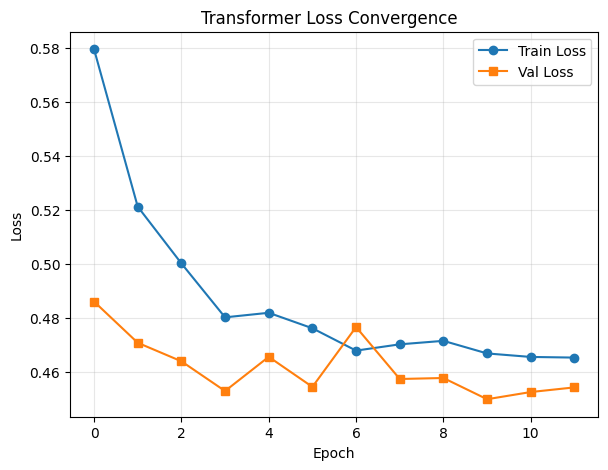

In [ ]:
# ============================================================
# 📈 Transformer Performance Charts
# ============================================================


# Loss Convergence ( Divergence Check)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.title("Transformer Loss Convergence  ")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

#  Probability Distribution ( U-Shape Test)
model_tf.eval()
all_final_probs = []
with torch.no_grad():
    for xb, dtb, mb, yb in val_loader:
        p = torch.softmax(model_tf(xb, pad_mask=mb), dim=1)[:, 1]
        all_final_probs.extend(p.cpu().numpy())




print(f"✅ Best Transformer validation F1: {best_val_f1_tf:.4f}")
print(f"✅ Best Transformer epoch: {best_epoch_tf}")
print(f"✅ Best Transformer threshold: {best_thr_tf:.2f}")
print(f"\n📊 Final Diagnostic:")
print(f"Best Val F1: {best_val_f1_tf:.4f}")
print(f"Convergence Status: {'Healthy' if history['val_loss'][-1] <= history['val_loss'][0] else 'Diverging'}")


### Eval

###### Full

[Transformer] Test ROC-AUC: 0.8303 | PR-AUC: 0.7309

📊 Transformer Final Report:
Best Val F1: 0.6523
Test F1    : 0.6372 (at thr=0.26)


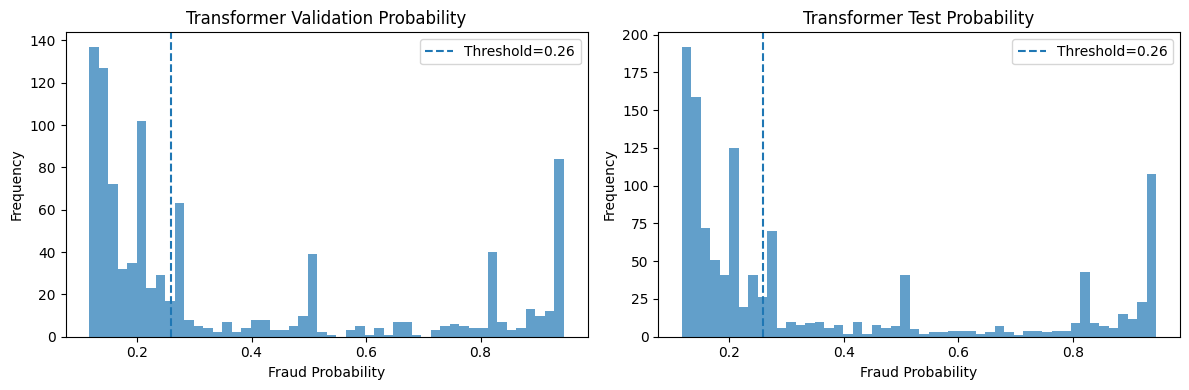


📊 Transformer Confusion Matrix


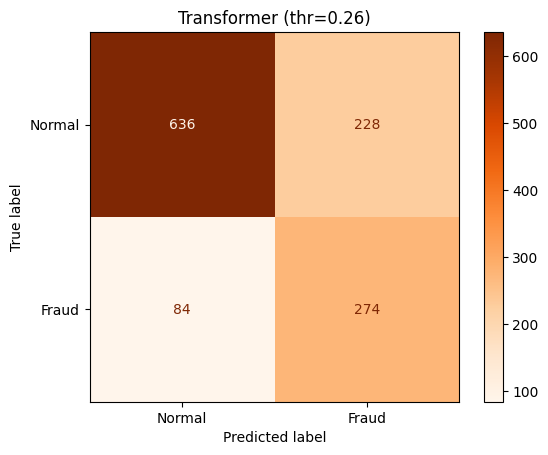


📊 Detailed Report: Transformer
              precision    recall  f1-score   support

      Normal     0.8833    0.7361    0.8030       864
       Fraud     0.5458    0.7654    0.6372       358

    accuracy                         0.7447      1222
   macro avg     0.7146    0.7507    0.7201      1222
weighted avg     0.7845    0.7447    0.7545      1222



,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
2,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61
3,4M,4,TransformerFraud,0.6372,0.8303,0.7654,0.5458,0.26


In [ ]:
# ============================================================
# Test Inference
# ============================================================
model_tf.eval()
test_loader = DataLoader(test_ds, batch_size=transformer_parameters["batch_size"], shuffle=False)

preds = []
val_loss_sum = 0.0
with torch.no_grad():
    for xb, dtb, mb, yb in test_loader:
        #logits = model_tf(xb, dtb, pad_mask=mb)
        logits = model_tf(xb, pad_mask=mb)
        probs = torch.softmax(logits, dim=1)[:, 1]  # Probability of class 1
        preds.append(probs.cpu().numpy())

p_te = np.concatenate(preds)

# ============================================================
# Metrics
# ============================================================
auc = roc_auc_score(yte, p_te)
ap  = average_precision_score(yte, p_te)
print(f"[Transformer] Test ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")
# ============================================================
# ✅ Transformer Generalization Gap
# ============================================================
model_tf.eval()
test_preds_binary = (p_te >= best_thr_tf).astype(int)
test_f1_tf = f1_score(yte, test_preds_binary, zero_division=0)
#gen_gap_tf = best_val_f1_tf - test_f1_tf

print(f"\n📊 Transformer Final Report:")
print(f"Best Val F1: {best_val_f1_tf:.4f}")
print(f"Test F1    : {test_f1_tf:.4f} (at thr={best_thr_tf:.2f})")
#print(f"Gen. Gap   : {gen_gap_tf:.4f}")



# ============================================================
# Use validation-selected threshold from training
# ============================================================
pred_label = (p_te >= best_thr_tf).astype(int)
best_f1_tf_test = f1_score(yte, pred_label, zero_division=0)
# ============================================================
# Transformer Gap Evaluation
# ============================================================

def get_transformer_probs(model, loader, device):
    model.eval()
    probs_list = []

    with torch.no_grad():
        for xb, dtb, mb, yb in loader:
            logits = model(xb, pad_mask=mb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            probs_list.append(probs.cpu().numpy())

    return np.concatenate(probs_list)

tf_train_probs = get_transformer_probs(model_tf, train_eval_loader_tf, device)
tf_val_probs   = get_transformer_probs(model_tf, val_loader, device)
tf_test_probs  = get_transformer_probs(model_tf, test_loader, device)

tf_train_f1 = f1_score(ytr, (tf_train_probs >= best_thr_tf).astype(int), zero_division=0)
tf_val_f1   = f1_score(yval, (tf_val_probs   >= best_thr_tf).astype(int), zero_division=0)
tf_test_f1  = f1_score(yte, (tf_test_probs  >= best_thr_tf).astype(int), zero_division=0)

gap_table = append_gap_result(
    gap_table,
    "TransformerFraud",
    tf_train_f1,
    tf_val_f1,
    tf_test_f1,
    best_thr_tf
)

plot_probability_distribution(
    "Transformer",
    tf_val_probs,
    tf_test_probs,
    best_thr_tf
)

precision = precision_score(yte, pred_label, zero_division=0)
recall = recall_score(yte, pred_label, zero_division=0)
f1 = best_f1_tf_test
# ============================================================
# Store results
# ============================================================
results = {
    "NAS SL": Base_SL,
    "Testing SL": max_seq_len,
    "f1":        f1,
    "auc":       auc,
    "recall":    recall,
    "precision": precision,
    "threshold": best_thr_tf,
}

summary = append_to_summary(summary, "TransformerFraud", results)
# ============================================================
# 📊 Transformer Confusion Matrix
# ============================================================

print("\n📊 Transformer Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    yte,
    pred_label,
    display_labels=["Normal", "Fraud"],
    cmap="Oranges"
)
plt.title(f"Transformer (thr={best_thr_tf:.2f})")
plt.show()
print_detailed_report("Transformer", yte, pred_label)
display(summary)


###### Evaluate progressive

In [ ]:

# ============================
# ✅ Progressive Evaluation
# ============================

tf_round_df = evaluate_transformer_progressive(
    model=model_tf,
    events=test_events_unscaled,
    users=users_te,
    feature_cols=feature_cols_tf,
    max_seq_len=max_seq_len_tf,
    recent_mode=recent_mode
)

# Add model label
#tf_round_df["Model"] = "Transformer"
tf_round_df["Model"] = "TransformerFraud"

# Remove old Transformer rows and append new
results_table = results_table[results_table["Model"] != "TransformerFraud"]
results_table = pd.concat([results_table, tf_round_df], ignore_index=True)


[Transformer] Starting progressive evaluation (4 rounds)...
[Transformer] Using feature columns: ['arpu_value', 'call_dur', 'calltype_id', 'dt_hours', 'flow', 'flow_norm', 'idcard_cnt', 'source_id']
[Transformer] Adding missing 'source_id' to events...
[Transformer] Total users to evaluate: 1222
[Transformer] Round 1/4...
[Transformer] Round 1: AUC=0.8039, Precision=0.3848, Recall=0.9050, F1=0.5400, thr=0.26
[Transformer] Round 2/4...
[Transformer] Round 2: AUC=0.8152, Precision=0.4405, Recall=0.8268, F1=0.5748, thr=0.26
[Transformer] Round 3/4...
[Transformer] Round 3: AUC=0.8231, Precision=0.4698, Recall=0.8045, F1=0.5932, thr=0.26
[Transformer] Round 4/4...
[Transformer] Round 4: AUC=0.8303, Precision=0.5458, Recall=0.7654, F1=0.6372, thr=0.26
[Transformer] Progressive evaluation complete.


##### Show

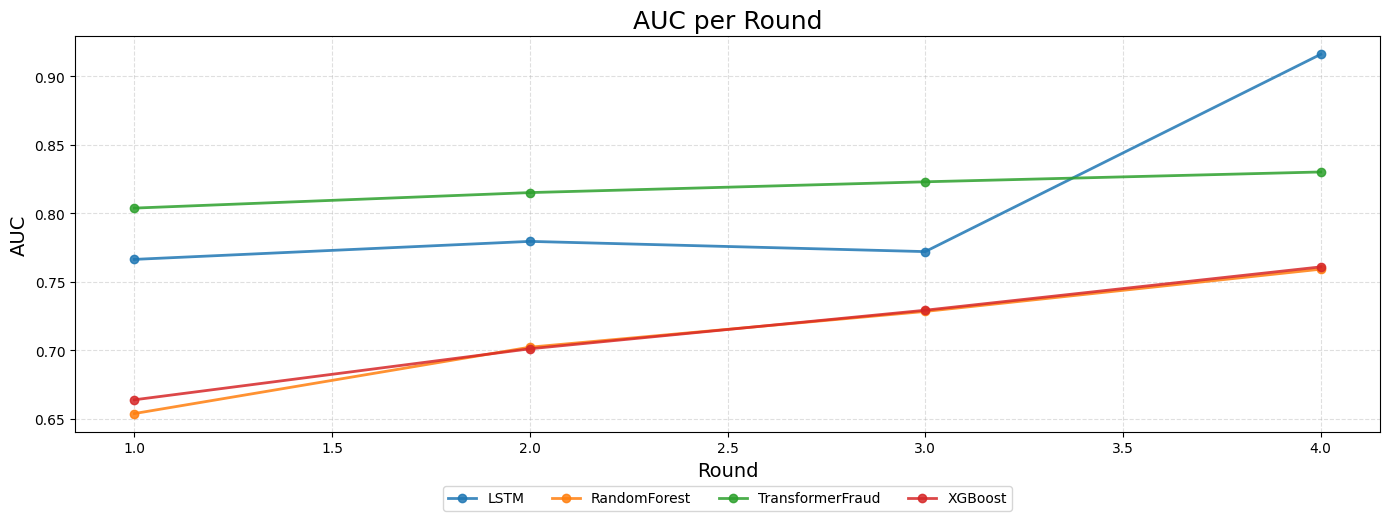

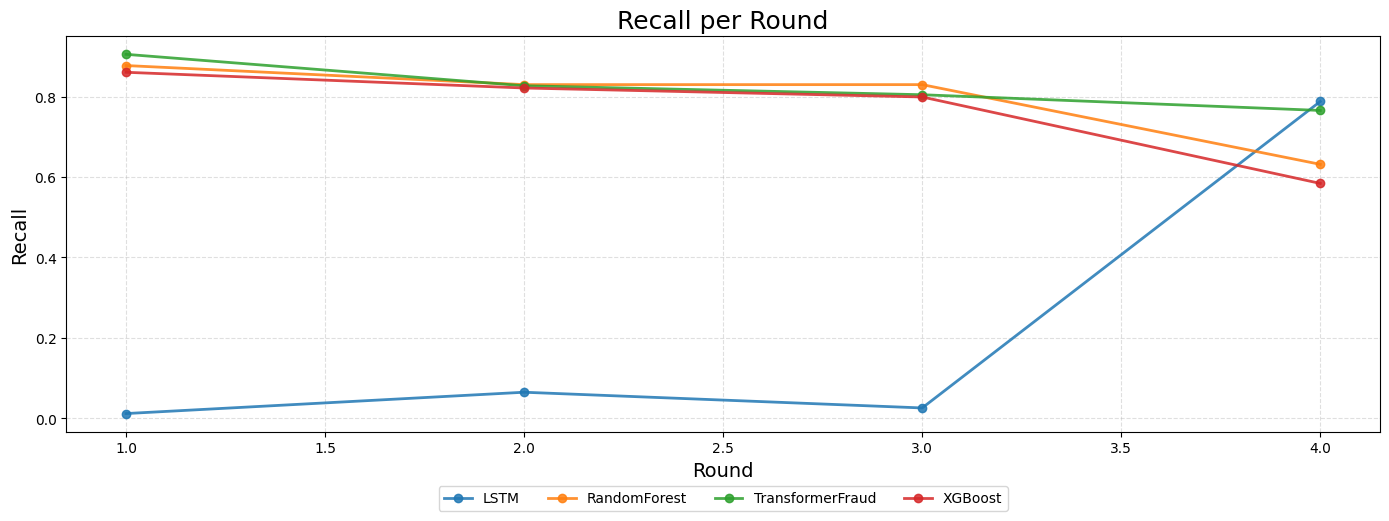

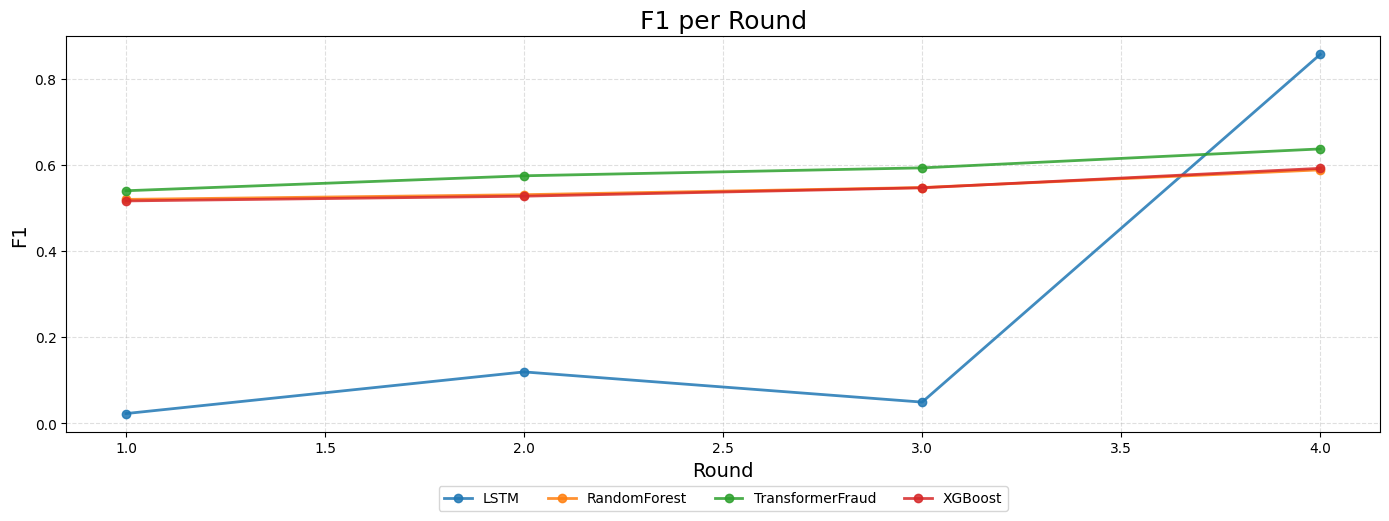

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round
0,4M,4,LSTM,0.022039,0.766467,0.011173,0.800000,0.61,1
1,4M,4,RandomForest,0.519868,0.653908,0.877095,0.369412,0.31,1
2,4M,4,TransformerFraud,0.540000,0.803915,0.905028,0.384798,0.26,1
3,4M,4,XGBoost,0.516345,0.663948,0.860335,0.368862,0.45,1
4,4M,4,LSTM,0.118863,0.779616,0.064246,0.793103,0.61,2
5,4M,4,RandomForest,0.530831,0.702360,0.829609,0.390276,0.31,2
6,4M,4,TransformerFraud,0.574757,0.815237,0.826816,0.440476,0.26,2
7,4M,4,XGBoost,0.527354,0.701187,0.821229,0.388375,0.45,2
8,4M,4,LSTM,0.048649,0.772149,0.025140,0.750000,0.61,3
9,4M,4,RandomForest,0.547465,0.728462,0.829609,0.408528,0.31,3


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
2,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
3,4M,4,TransformerFraud,0.6372,0.8303,0.7654,0.5458,0.26
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,LSTM,0.8437,0.8620,0.8571,-0.0183,-0.0135,0.0049,0.61
1,RandomForest,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
2,TransformerFraud,0.6431,0.6523,0.6372,-0.0092,0.0059,0.0151,0.26
3,XGBoost,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


In [ ]:
plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col="Round"
)
display(summary.sort_values(by="Model"))

display(gap_table.sort_values("Model").reset_index(drop=True))


#Pretrained

#TimesNet

## Preparation

###Install

In [ ]:


# ============================
# 1️⃣ Clean up any old copies only if you did not made any customzation to the code
# ============================
#!rm -rf /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library

# ============================
# 2️⃣ Clone directly from gethub
# ============================
#!git clone https://github.com/thuml/Time-Series-Library.git /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library

# ============================
# 3️⃣ Add repo to Python path
# ============================
import sys
sys.path.append('/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library')

print("✅ Basic environment ready for TSLib!")

# ============================
# 4️⃣ Verify repo structure
# ============================
%cd /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library
!ls -lh run.py

run_py = (
    "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
    "Time-Series-Library/run.py"
)
data_path= f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}/"



✅ Basic environment ready for TSLib!
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library
-rw------- 1 root root 16K Apr 29 16:31 run.py


### Helper

In [ ]:
def evaluate_experiment(
    results_dir: str,
    threshold,
    num_classes: int = None,
    class_labels=None,
    title: str = None,
    show_plot: bool = True,
):
    pred_path = os.path.join(results_dir, "pred.npy")
    true_path = os.path.join(results_dir, "true.npy")
    prob_path = os.path.join(results_dir, "prob.npy")

    if not os.path.exists(pred_path) or not os.path.exists(true_path):
        raise FileNotFoundError(f"❌ Could not find pred.npy or true.npy in {results_dir}")

    true = np.load(true_path).flatten()

    # ── Probabilities available → use passed validation threshold ──
    if os.path.exists(prob_path):
        probs = np.load(prob_path).flatten()

        try:
            auc_val = roc_auc_score(true, probs) if len(np.unique(true)) == 2 else np.nan
        except:
            auc_val = np.nan

        pred = (probs >= threshold).astype(int)
        best_thr = threshold

    # ── Fallback → hard labels only ──
    else:
        pred = np.load(pred_path).flatten()
        best_thr = 0.5
        try:
            auc_val = roc_auc_score(true, pred) if len(np.unique(true)) == 2 else np.nan
        except:
            auc_val = np.nan

    # ── Metrics from final pred ──
    acc  = accuracy_score(true, pred)
    prec = precision_score(true, pred, average="binary", zero_division=0)
    rec  = recall_score(true, pred, average="binary", zero_division=0)
    f1   = f1_score(true, pred, average="binary", zero_division=0)

    # ── Confusion matrix ──
    cm = confusion_matrix(true, pred)
    if class_labels is None:
        class_labels = [str(c) for c in np.unique(true)]

    # ── Plot ──
    if show_plot:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
        plt.figure(figsize=(8, 8))
        disp.plot(cmap="Blues", values_format="d", colorbar=False)
        plt.title(title or f"Confusion Matrix ({os.path.basename(results_dir)})")
        plt.show()

    # ── Print ──
    print(f"\n📊 Accuracy: {acc:.4f}")
    print(f"📈 Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_val:.4f}")
    print(f"🎯 Threshold: {best_thr:.3f}")
    print("\nDetailed Report:")
    print(classification_report(true, pred, target_names=class_labels, digits=4))

    return {
        "NAS SL": Base_SL,
        "Testing SL": max_seq_len,
        "f1": f1,
        "accuracy": acc,
        "recall": rec,
        "precision": prec,
        "auc": auc_val,
        "confusion_matrix": cm,
        "threshold": round(best_thr, 3),
    }


#Covert data to ts format
def write_ts_file(
    X, y, split_name,
    problem_name="FraudDataset",
    out_dir=None,
    pad_to_dim=None,
    round_id=None
):


    if out_dir is None:
        out_dir = f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}"
    os.makedirs(out_dir, exist_ok=True)
    suffix = f"_R{round_id}" if round_id is not None else ""
    ts_path = os.path.join(
        out_dir,
        f"{problem_name}_{split_name.upper()}{suffix}.ts"
    )


    with open(ts_path, "w") as f:
        f.write(f"@problemName {problem_name}\n")
        f.write("@timeStamps false\n")
        f.write("@univariate false\n")
        f.write("@classLabel true 0 1\n")
        f.write("@data\n")

        for i in range(len(X)):
            arr = np.array(X[i])

            # --- Pad or trim to target feature dimension ---
            if pad_to_dim is not None:
                if arr.ndim == 1:
                    arr = arr.reshape(-1, 1)
                n_dim = arr.shape[1]
                if n_dim < pad_to_dim:
                    pad = np.zeros((arr.shape[0], pad_to_dim - n_dim))
                    arr = np.hstack((arr, pad))
                elif n_dim > pad_to_dim:
                    arr = arr[:, :pad_to_dim]

            # --- Convert to string format ---
            if arr.ndim == 1:
                arr_str = ",".join(map(str, arr))
            else:
                parts = [",".join(map(str, arr[:, d])) for d in range(arr.shape[1])]
                arr_str = " : ".join(parts)  # colon separates dimensions

            f.write(f"{arr_str}:{int(y[i])}\n")

    print(f"✅ Wrote {ts_path} with {len(X)} samples (strict sktime format)")
    if pad_to_dim:
        print(f"📏 Feature dimensions padded/trimmed to {pad_to_dim}")


def get_timesnet_val_threshold(results_dir):
    """Finds best threshold on validation set """
    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    if not os.path.exists(val_prob_path): return 0.5, 0.0

    val_probs = np.load(val_prob_path).flatten()
    val_true = np.load(val_true_path).flatten()

    best_f1, best_thr = -1.0, 0.5
    for thr in np.linspace(0.2, 0.8, 61):
        f1 = f1_score(val_true, (val_probs >= thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def plot_timesnet_diagnostics(probs, labels, threshold, title):
    """Generates Point 8 (U-Shape) and Point 10 (CM) graphs"""
    plt.figure(figsize=(12, 5))

    # Left: Probability Distribution
    plt.subplot(1, 2, 1)
    plt.hist(probs, bins=50, color='teal', alpha=0.7)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Best Thr: {threshold:.2f}')
    plt.title(f"{title} - Prob Distribution  ")
    plt.xlabel("Fraud Probability")
    plt.legend()

    # Right: Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(labels, (probs >= threshold).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f"{title} - Matrix")
    plt.show()

def append_timesnet_gap(gap_table, model_name, results_dir, threshold):
    train_prob_path = os.path.join(results_dir, "train_prob.npy")
    train_true_path = os.path.join(results_dir, "train_true.npy")

    val_prob_path = os.path.join(results_dir, "val_prob.npy")
    val_true_path = os.path.join(results_dir, "val_true.npy")

    test_prob_path = os.path.join(results_dir, "prob.npy")
    test_true_path = os.path.join(results_dir, "true.npy")

    if not all(os.path.exists(p) for p in [
        train_prob_path, train_true_path,
        val_prob_path, val_true_path,
        test_prob_path, test_true_path
    ]):
        print(f"⚠️ {model_name}: train/val/test probability files are not complete.")
        return gap_table

    train_probs = np.load(train_prob_path).flatten()
    train_true  = np.load(train_true_path).flatten()

    val_probs = np.load(val_prob_path).flatten()
    val_true  = np.load(val_true_path).flatten()

    test_probs = np.load(test_prob_path).flatten()
    test_true  = np.load(test_true_path).flatten()

    train_f1 = f1_score(train_true, (train_probs >= threshold).astype(int), zero_division=0)
    val_f1   = f1_score(val_true,   (val_probs   >= threshold).astype(int), zero_division=0)
    test_f1  = f1_score(test_true,  (test_probs  >= threshold).astype(int), zero_division=0)

    return append_gap_result(
        gap_table,
        model_name,
        train_f1,
        val_f1,
        test_f1,
        threshold
    )

def plot_timesnet_loss(results_dir, model_name):
    loss_path = os.path.join(results_dir, "loss_history.csv")

    if not os.path.exists(loss_path):
        print(f"⚠️ {model_name}: loss_history.csv not found.")
        return

    df_loss = pd.read_csv(loss_path)

    plt.figure(figsize=(8, 5))
    plt.plot(df_loss["epoch"], df_loss["train_loss"], label="Train Loss")
    plt.plot(df_loss["epoch"], df_loss["val_loss"], label="Val Loss")
    plt.plot(df_loss["epoch"], df_loss["test_loss"], label="Test Loss", linestyle="--")

    plt.title(f"{model_name} Loss Convergence")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    display(df_loss)


### Covert  data to ts format

In [ ]:

write_ts_file(trans_X_train, trans_y_train, split_name="TRAIN", pad_to_dim=13)
write_ts_file(trans_X_test, trans_y_test, split_name="TEST", pad_to_dim=13)
write_ts_file(trans_X_val, trans_y_val, split_name="VAL", pad_to_dim=13)



✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_4_4M/FraudDataset_TRAIN.ts with 3907 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13
✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_4_4M/FraudDataset_TEST.ts with 1222 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13
✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_4_4M/FraudDataset_VAL.ts with 977 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13


### Show sample and Summrize

In [ ]:
file_path = f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}/FraudDataset_TRAIN.ts"
X, y = load_from_tsfile_to_dataframe(file_path)

print("✅ Loaded OK!")
print(X.shape)
print(set(y))

#ts_dir = f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}"

for fname in ["FraudDataset_TRAIN.ts", "FraudDataset_TEST.ts"]:
    fpath = os.path.join(data_path, fname)
    print(f" {fname}: exists = {os.path.exists(fpath)} | size = {os.path.getsize(fpath)/1024:.1f} KB")
    if os.path.exists(fpath):
        with open(fpath) as f:
            for i, line in enumerate(f):
                if i < 10:
                    print(line.strip())
                else:
                    break
        print("------\n")



X, y = load_from_tsfile_to_dataframe(file_path)

print("✅ File loaded successfully!")
print(f"Shape of X: {X.shape}")
print(f"Number of labels: {len(set(y))}")
print(f"Labels: {set(y)}")
#print(f"Example (first row):\n", X.iloc[0])

print("Feature ranges per column:")
for col in range(X.shape[1]):
    values = np.concatenate(X.iloc[:, col].values)
    print(f"Column {col}: mean={np.mean(values):.3f}, std={np.std(values):.3f}")


✅ Loaded OK!
(3907, 13)
{np.str_('0'), np.str_('1')}
 FraudDataset_TRAIN.ts: exists = True | size = 2643.7 KB
@problemName FraudDataset
@timeStamps false
@univariate false
@classLabel true 0 1
@data
-0.024693284541574396,-0.024693284541574396,-0.024693284541574396,6.481136320136848 : -0.21466702029441828,-0.13641853975907814,-0.23205557152449388,-0.23205557152449388 : -0.4057440026627665,-0.4057440026627665,0.8274927073856597,-1.6389807127111926 : -0.04290786539071689,-0.04290786539071689,-0.04290786539071689,-0.04290786539071689 : -0.25151520010684936,-0.25151520010684936,-0.25151520010684936,-0.25151520010684936 : 1.8135005156869577,1.8135005156869577,1.8135005156869577,1.8135005156869577 : -0.38929239132431154,-0.44632520626058275,4.866957530128883,5.81074667252977 : 3.0,3.0,1.0,2.0 : 0.0,0.0,0.0,0.0 : 0.0,0.0,0.0,0.0 : 0.0,0.0,0.0,0.0 : 0.0,0.0,0.0,0.0 : 0.0,0.0,0.0,0.0:1
21.671491955246466,2.8499756105488916,2.8499756105488916,2.8499756105488916 : -0.23205557152449388,-0.232055571

### Model and training

###### Head Partial unfreeze ▶(classifier (head/fc/projection)

In [ ]:

print(f"[{datetime.now()}] 🚀 Starting TimesNet PartialUnfreeze training...")

print("seq len", max_seq_len)
print("datapath", data_path)

!CUDA_VISIBLE_DEVICES=0 \
python -u /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library/run.py \
  --task_name classification \
  --is_training 1 \
  --mode PartialUnfreeze \
  --root_path $data_path \
  --model_id FraudDataset_PartialUnfreeze \
  --model TimesNet \
  --data UEA \
  --data_path FraudDataset \
  --features M \
  --seq_len $max_seq_len \
  --num_kernels $_tn_num_kernels \
  --target OT \
  --gpu 0 \
  --use_gpu 1 \
  --train_epochs $epochs \
  --patience $_tn_patience \
  --batch_size $_tn_batch_size \
  --learning_rate $_tn_learning_rate \
  --e_layers $_tn_e_layers \
  --d_model $_tn_d_model \
  --d_ff $_tn_d_ff \
  --top_k $_tn_top_k \
  --dropout $_tn_dropout \
  --des PartialUnfreeze \
  --itr 1

print(f"[{datetime.now()}] ✅ TimesNet PartialUnfreeze training complete")

# ==========================================================
# ==========================================================
print(f"[{datetime.now()}] 📊 Evaluating PartialUnfreeze...")

results_dir = (
    f"./test_results/"
    f"classification_FraudDataset_PartialUnfreeze_"
    f"TimesNet_UEA_ftM_"
    f"sl{max_seq_len}_"
    f"ll48_"
    f"pl0_"
    f"dm{timesnet_parameters['d_model']}_"
    f"nh8_"
    f"el{timesnet_parameters['e_layers']}_"
    f"dl1_"
    f"df{timesnet_parameters['d_ff']}_"
    f"expand2_"
    f"dc4_"
    f"fc1_"
    f"ebtimeF_"
    f"dtTrue_"
    f"PartialUnfreeze_0"
)


[2026-07-08 10:08:48.134719] 🚀 Starting TimesNet PartialUnfreeze training...
seq len 4
datapath /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_4_4M/
Using GPU
Use GPU: cuda:0
🔧 Building model and loading metadata...

========== Experiment Arguments ==========
activation               : gelu
alpha                    : 0.1
anomaly_ratio            : 0.25
augmentation_ratio       : 0
batch_size               : 8
c_out                    : 7
channel_independence     : 1
checkpoints              : ./checkpoints/
conv_channel             : 32
d_conv                   : 4
d_ff                     : 32
d_layers                 : 1
d_model                  : 32
data                     : UEA
data_path                : FraudDataset
dec_in                   : 7
decomp_method            : moving_avg
des                      : PartialUnfreeze
device                   : cuda:0
devices                  : 0,1,2,3
discdtw                 

[DEBUG] Using path: ./test_results/classification_FraudDataset_PartialUnfreeze_TimesNet_UEA_ftM_sl4_ll48_pl0_dm32_nh8_el2_dl1_df32_expand2_dc4_fc1_ebtimeF_dtTrue_PartialUnfreeze_0
  ✅ TimesNet_PartialUnfreeze validation threshold: 0.54 | val_f1=0.8180


<Figure size 800x800 with 0 Axes>

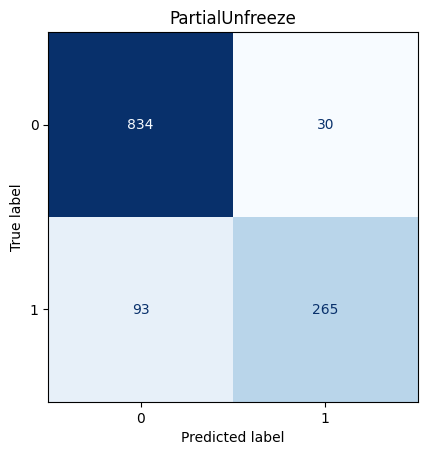


📊 Accuracy: 0.8993
📈 Precision: 0.8983 | Recall: 0.7402 | F1: 0.8116 | AUC: 0.8938
🎯 Threshold: 0.540

Detailed Report:
              precision    recall  f1-score   support

           0     0.8997    0.9653    0.9313       864
           1     0.8983    0.7402    0.8116       358

    accuracy                         0.8993      1222
   macro avg     0.8990    0.8528    0.8715      1222
weighted avg     0.8993    0.8993    0.8963      1222



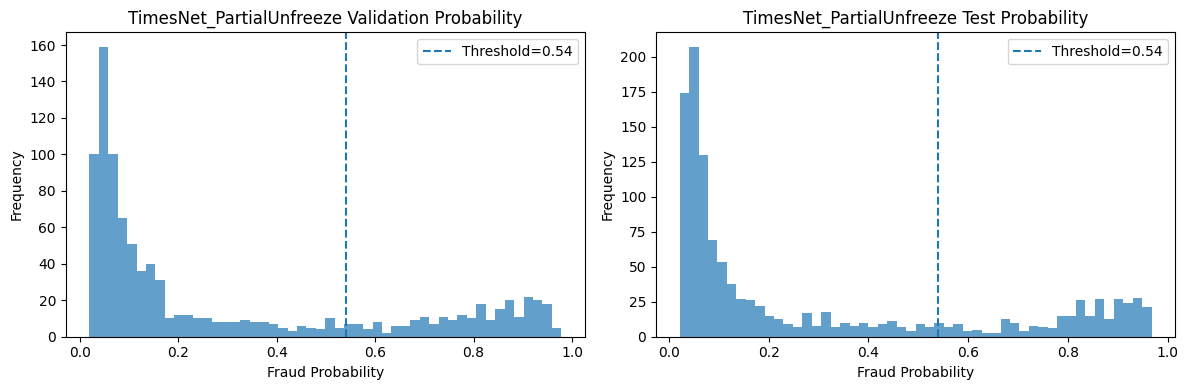

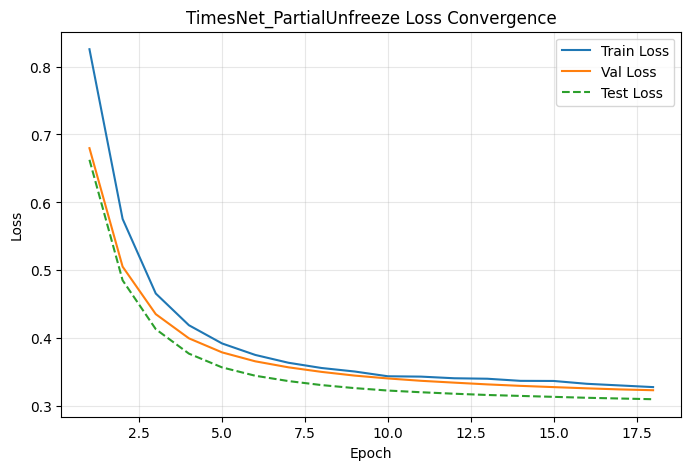

,epoch,time_sec,train_loss,val_loss,val_f1,test_loss,test_f1
0,1,10.644630,0.825532,0.679850,0.524476,0.662709,0.553055
1,2,8.269847,0.575646,0.505370,0.700491,0.485251,0.722513
2,3,8.324629,0.465838,0.435450,0.750449,0.413334,0.752604
3,4,8.145641,0.419127,0.399838,0.757522,0.377305,0.765900
4,5,8.284227,0.392292,0.379154,0.776801,0.357042,0.776119
5,6,8.288223,0.375407,0.366001,0.795775,0.344760,0.787551
6,7,8.329473,0.363900,0.357169,0.794425,0.336920,0.788520
7,8,8.322871,0.356158,0.350439,0.798574,0.331010,0.798799
8,9,8.294722,0.350987,0.344964,0.805009,0.326532,0.805970
9,10,8.246144,0.343983,0.340779,0.807829,0.322961,0.812030


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
2,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61
3,4M,4,TransformerFraud,0.6372,0.8303,0.7654,0.5458,0.26
4,4M,4,TimesNet_PartialUnfreeze,0.8116,0.8938,0.7402,0.8983,0.54


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,LSTM,0.8437,0.8620,0.8571,-0.0183,-0.0135,0.0049,0.61
1,RandomForest,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
2,TimesNet_PartialUnfreeze,0.7917,0.8180,0.8116,-0.0263,-0.0200,0.0064,0.54
3,TransformerFraud,0.6431,0.6523,0.6372,-0.0092,0.0059,0.0151,0.26
4,XGBoost,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


In [ ]:

print(f"[DEBUG] Using path: {results_dir}")
best_thr_tn, best_f1_tn_val = get_timesnet_val_threshold(results_dir)
print(f"  ✅ TimesNet_PartialUnfreeze validation threshold: {best_thr_tn:.2f} | val_f1={best_f1_tn_val:.4f}")

results_partial = evaluate_experiment(
    results_dir,
    threshold=best_thr_tn,
    num_classes=2,
    title="PartialUnfreeze"
)

summary = append_to_summary(summary, "TimesNet_PartialUnfreeze", results_partial)


gap_table = append_timesnet_gap(
    gap_table,
    "TimesNet_PartialUnfreeze",
    results_dir,
    best_thr_tn
)
tn_val_probs = np.load(os.path.join(results_dir, "val_prob.npy")).flatten()
tn_test_probs = np.load(os.path.join(results_dir, "prob.npy")).flatten()

plot_probability_distribution(
    "TimesNet_PartialUnfreeze",
    tn_val_probs,
    tn_test_probs,
    best_thr_tn
)
plot_timesnet_loss(
    results_dir,
    "TimesNet_PartialUnfreeze"
)
display(summary)
display(gap_table.sort_values("Model").reset_index(drop=True))


##### Full training

In [ ]:

print(f"[{datetime.now()}] 🚀 Starting TimesNet Unfreeze training...")

!CUDA_VISIBLE_DEVICES=0 \
python -u /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/Time-Series-Library/run.py \
  --task_name classification \
  --is_training 1 \
  --mode UnfrozenOptWL \
  --root_path $data_path \
  --model_id FraudDataset_Unfrozen \
  --model TimesNet \
  --data UEA \
  --data_path FraudDataset \
  --features M \
  --seq_len $max_seq_len \
  --num_kernels $_tn_num_kernels \
  --target OT \
  --gpu 0 \
  --use_gpu 1 \
  --train_epochs $epochs \
  --patience $_tn_patience \
  --batch_size $_tn_batch_size \
  --learning_rate $_tn_learning_rate \
  --e_layers $_tn_e_layers \
  --d_model $_tn_d_model \
  --d_ff $_tn_d_ff \
  --top_k $_tn_top_k \
  --dropout $_tn_dropout \
  --des UnfrozenOptWL \
  --itr 1

print(f"[{datetime.now()}]  TimesNet Unfreeze training complete")


[2026-07-08 10:12:58.914988] 🚀 Starting TimesNet Unfreeze training...
Using GPU
Use UnfrozenOptWL
Use GPU: cuda:0
🔧 Building model and loading metadata...

========== Experiment Arguments ==========
activation               : gelu
alpha                    : 0.1
anomaly_ratio            : 0.25
augmentation_ratio       : 0
batch_size               : 8
c_out                    : 7
channel_independence     : 1
checkpoints              : ./checkpoints/
conv_channel             : 32
d_conv                   : 4
d_ff                     : 32
d_layers                 : 1
d_model                  : 32
data                     : UEA
data_path                : FraudDataset
dec_in                   : 7
decomp_method            : moving_avg
des                      : UnfrozenOptWL
device                   : cuda:0
devices                  : 0,1,2,3
discdtw                  : False
discsdtw                 : False
distil                   : True
down_sampling_layers     : 0
down_sampling_method     

[DEBUG] Using path: ./test_results/classification_FraudDataset_Unfrozen_TimesNet_UEA_ftM_sl4_ll48_pl0_dm32_nh8_el2_dl1_df32_expand2_dc4_fc1_ebtimeF_dtTrue_UnfrozenOptWL_0
  ✅ TimesNet_Unfrozen validation threshold: 0.53 | val_f1=0.8479


<Figure size 800x800 with 0 Axes>

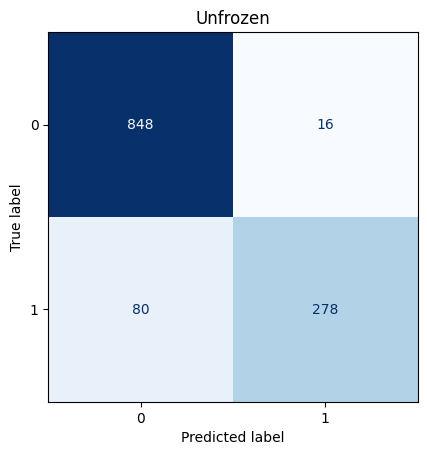


📊 Accuracy: 0.9214
📈 Precision: 0.9456 | Recall: 0.7765 | F1: 0.8528 | AUC: 0.9166
🎯 Threshold: 0.530

Detailed Report:
              precision    recall  f1-score   support

           0     0.9138    0.9815    0.9464       864
           1     0.9456    0.7765    0.8528       358

    accuracy                         0.9214      1222
   macro avg     0.9297    0.8790    0.8996      1222
weighted avg     0.9231    0.9214    0.9190      1222



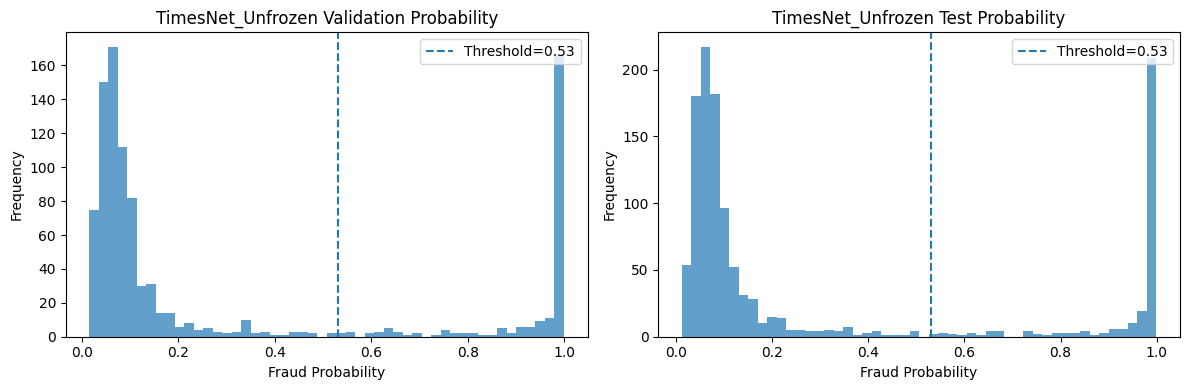

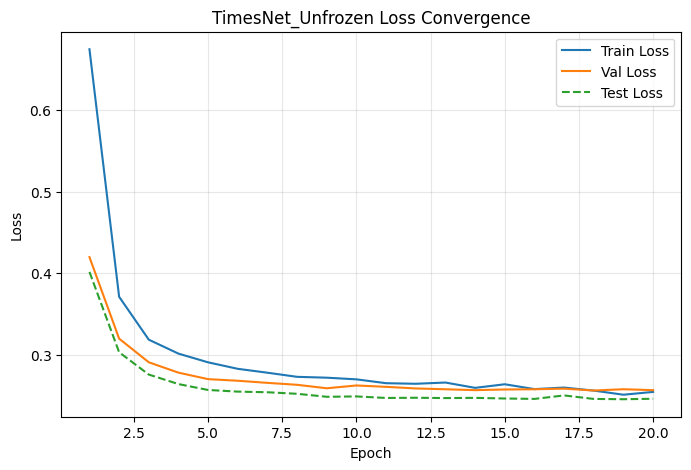

,epoch,time_sec,train_loss,val_loss,val_f1,test_loss,test_f1
0,1,14.931046,0.674518,0.419617,0.746429,0.401451,0.763314
1,2,13.075003,0.370966,0.319626,0.809187,0.302962,0.825633
2,3,13.190198,0.318354,0.290626,0.825758,0.275571,0.844118
3,4,13.069499,0.301257,0.277938,0.831068,0.263927,0.851064
4,5,13.160531,0.290564,0.269957,0.834951,0.256678,0.850998
5,6,13.129482,0.282616,0.267989,0.831373,0.254666,0.853253
6,7,13.170377,0.277842,0.265400,0.833333,0.253892,0.859281
7,8,13.226257,0.272797,0.263022,0.837838,0.251996,0.864458
8,9,13.232357,0.271744,0.258770,0.840951,0.248327,0.855828
9,10,13.196679,0.269713,0.262196,0.838207,0.248778,0.852359


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
2,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61
3,4M,4,TransformerFraud,0.6372,0.8303,0.7654,0.5458,0.26
4,4M,4,TimesNet_PartialUnfreeze,0.8116,0.8938,0.7402,0.8983,0.54
5,4M,4,TimesNet_Unfrozen,0.8528,0.9166,0.7765,0.9456,0.53


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,LSTM,0.8437,0.8620,0.8571,-0.0183,-0.0135,0.0049,0.61
1,RandomForest,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
2,TimesNet_PartialUnfreeze,0.7917,0.8180,0.8116,-0.0263,-0.0200,0.0064,0.54
3,TimesNet_Unfrozen,0.8484,0.8479,0.8528,0.0005,-0.0044,-0.0049,0.53
4,TransformerFraud,0.6431,0.6523,0.6372,-0.0092,0.0059,0.0151,0.26
5,XGBoost,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


In [ ]:

# ==========================================================
# EVALUATE NAS BEST (Unfrozen mode)
# ==========================================================

results_dir_unfrozen = (
    f"./test_results/"
    f"classification_FraudDataset_Unfrozen_"
    f"TimesNet_UEA_ftM_"
    f"sl{max_seq_len}_"
    f"ll48_"
    f"pl0_"
    f"dm{timesnet_parameters['d_model']}_"
    f"nh8_"
    f"el{timesnet_parameters['e_layers']}_"
    f"dl1_"
    #f"df64_"
    f"df{timesnet_parameters['d_ff']}_"
    f"expand2_"
    f"dc4_"
    f"fc1_"
    f"ebtimeF_"
    f"dtTrue_"
    f"UnfrozenOptWL_0"
)


print(f"[DEBUG] Using path: {results_dir_unfrozen}")

best_thr_tn_unfrozen, best_f1_tn_val_unfrozen = get_timesnet_val_threshold(results_dir_unfrozen)
print(f"  ✅ TimesNet_Unfrozen validation threshold: {best_thr_tn_unfrozen:.2f} | val_f1={best_f1_tn_val_unfrozen:.4f}")

results_unfrozen = evaluate_experiment(
    results_dir_unfrozen,
    threshold=best_thr_tn_unfrozen,
    num_classes=2,
    title="Unfrozen"
)

gap_table = append_timesnet_gap(
    gap_table,
    "TimesNet_Unfrozen",
    results_dir_unfrozen,
    best_thr_tn_unfrozen
)
tn_val_probs = np.load(os.path.join(results_dir_unfrozen, "val_prob.npy")).flatten()
tn_test_probs = np.load(os.path.join(results_dir_unfrozen, "prob.npy")).flatten()

plot_probability_distribution(
    "TimesNet_Unfrozen",
    tn_val_probs,
    tn_test_probs,
    best_thr_tn_unfrozen
)
plot_timesnet_loss(
    results_dir_unfrozen,
    "TimesNet_Unfrozen"
)
summary = append_to_summary(summary, "TimesNet_Unfrozen", results_unfrozen)
display(summary)
display(gap_table.sort_values("Model").reset_index(drop=True))


##### Gradually for both

In [ ]:


def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def find_latest_results_dir(base="./test_results"):
    if not os.path.exists(base):
        raise RuntimeError("❌ test_results directory does not exist")

    candidates = [
        os.path.join(base, d)
        for d in os.listdir(base)
        if os.path.isdir(os.path.join(base, d))
    ]

    if not candidates:
        raise RuntimeError("❌ No TimesNet results directory found")

    return max(candidates, key=os.path.getmtime)

print(f"[{datetime.now()}] 🚀 Starting TimesNet Unfreeze Progressive Evaluation...")

ts_dir = (
    f"/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_{max_seq_len}_{Base_SL}/"
)


timesnet_modes = [
    {"mode": "UnfrozenOptWL", "model_id": "FraudDataset_Unfrozen", "label": "TimesNet_Unfrozen"},
    {"mode": "PartialUnfreeze", "model_id": "FraudDataset_PartialUnfreeze", "label": "TimesNet_PartialUnfreeze"},
]

for r in key_rounds:
    print(f"\n{'='*60}")
    print(f"[TimesNet] Round {r}/{max_seq_len}")
    print(f"{'='*60}")

    # --------------------------------------------------------
    # 1️⃣ Select events (ONCE per round)
    # --------------------------------------------------------
    if r == max_seq_len:
        event_selector = None  # Same as training
    else:
        event_selector = selector_oldest(r)  # Takes FIRST r events inside selected window

    X_r, y_r, users_r = make_user_sequences(
        test_events,
        feature_cols=numeric_features,
        max_seq_len=max_seq_len,
        event_selector=event_selector
    )

    print(f"users={len(users_r)}, X_r shape={X_r.shape}")

    # --------------------------------------------------------
    # 2️⃣ Write TEST.ts (ONCE per round)
    # --------------------------------------------------------
    write_ts_file(
        X_r,
        y_r,
        split_name="TEST",
        pad_to_dim=13,
        round_id=r
    )

    src = os.path.join(ts_dir, f"FraudDataset_TEST_R{r}.ts")
    dst = os.path.join(ts_dir, "FraudDataset_TEST.ts")

    shutil.copyfile(src, dst)
    time.sleep(0.5)###wait for file sync

    print(f"[DEBUG] TEST.ts hash (round {r}): {md5(dst)}")

    # --------------------------------------------------------
    # 3️⃣ Run BOTH modes on same data
    # --------------------------------------------------------
    for cfg in timesnet_modes:
        print(f"\n  → Running {cfg['label']}...")

        cmd = [
            "python", "-u", run_py,
            "--task_name", "classification",
            "--is_training", "0",
            "--mode", cfg["mode"],
            "--root_path", ts_dir,
            "--model_id", cfg["model_id"],
            "--model", "TimesNet",
            "--data", "UEA",
            "--data_path", "FraudDataset",
            "--features", "M",
            "--seq_len", str(max_seq_len),
            "--target", "OT",
            "--gpu", "0",
            "--use_gpu", "1",
            "--learning_rate", str(timesnet_parameters["learning_rate"]),
            "--num_kernels", str(timesnet_parameters["num_kernels"]),
            "--e_layers", str(timesnet_parameters["e_layers"]),
            "--d_model", str(timesnet_parameters["d_model"]),
            "--d_ff", str(timesnet_parameters["d_ff"]),
            "--top_k", str(timesnet_parameters["top_k"]),
            "--dropout", str(timesnet_parameters["dropout"]),
            "--batch_size", str(timesnet_parameters["batch_size"]),
            "--patience",      str(timesnet_parameters["patience"]),
            "--des", cfg["mode"],
            "--itr", "1",
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            print("❌ STDOUT:")
            print(result.stdout)
            print("\n❌ STDERR:")
            print(result.stderr)
            raise RuntimeError(f"TimesNet {cfg['mode']} inference failed for round {r}")

        # --------------------------------------------------------
        # 4️⃣ Locate results & Evaluate
        # --------------------------------------------------------
        results_dir = (
            f"./test_results/"
            f"classification_{cfg['model_id']}_TimesNet_UEA_ftM_"
            f"sl{max_seq_len}_ll48_pl0_"
            f"dm{timesnet_parameters['d_model']}_nh8_"
            f"el{timesnet_parameters['e_layers']}_dl1_"
            f"df{timesnet_parameters['d_ff']}_expand2_dc4_fc1_"
            f"ebtimeF_dtTrue_{cfg['mode']}_0"
        )
        print(f"  [DEBUG] results_dir: {results_dir}")

        pred_path = os.path.join(results_dir, "pred.npy")
        true_path = os.path.join(results_dir, "true.npy")

        if not os.path.exists(pred_path) or not os.path.exists(true_path):
            raise RuntimeError(
                f"❌ pred.npy / true.npy missing for {cfg['label']} round {r}\n"
                f"Checked: {results_dir}"
            )
        best_thr_tn, best_f1_tn_val = get_timesnet_val_threshold(results_dir)
        print(f"  ✅ {cfg['label']} validation threshold: {best_thr_tn:.2f} | val_f1={best_f1_tn_val:.4f}")
        metrics = evaluate_experiment(
            results_dir=results_dir,
            threshold=best_thr_tn,
            class_labels=["0", "1"],
            title=f"{cfg['label']} – Round {r}",
            show_plot=False
        )
        print(metrics.keys())
        # --------------------------------------------------------
        # 5️⃣ Store results
        # --------------------------------------------------------
        results_table = pd.concat(
          [
              results_table,
              pd.DataFrame([{
                  "NAS SL": Base_SL,
                  "Testing SL": max_seq_len,
                  "F1": metrics["f1"],
                  "Round": r,
                  "AUC": metrics["auc"],
                  "Recall": metrics["recall"],
                  "Precision": metrics["precision"],
                  "threshold": metrics["threshold"],
                  "Model": cfg["label"],
              }])
          ],
          ignore_index=True
      )

        print(
          f"  ✅ {cfg['label']}: "
          f"AUC={metrics['auc']:.4f}, "
          f"Precision={metrics['precision']:.4f}, "
          f"Recall={metrics['recall']:.4f}, "
          f"F1={metrics['f1']:.4f}, "
          f"thr={metrics['threshold']:.2f}"
      )

# ============================================================
# Display final results
# ============================================================
print(f"\n{'='*60}")
print("📊 FINAL RESULTS")
print(f"{'='*60}")
display(results_table)
print(f"[{datetime.now()}] 🚀 Ending TimesNet Unfreeze Progressive Evaluation...")



[2026-07-08 10:18:22.149737] 🚀 Starting TimesNet Unfreeze Progressive Evaluation...

[TimesNet] Round 1/4
users=1222, X_r shape=(1222, 4, 8)
✅ Wrote /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/ExternalDataset/TimesNet/classification/FraudDataset_4_4M/FraudDataset_TEST_R1.ts with 1222 samples (strict sktime format)
📏 Feature dimensions padded/trimmed to 13
[DEBUG] TEST.ts hash (round 1): 6b25fd36a455fa887fecca4cbdf69a4e

  → Running TimesNet_Unfrozen...
  [DEBUG] results_dir: ./test_results/classification_FraudDataset_Unfrozen_TimesNet_UEA_ftM_sl4_ll48_pl0_dm32_nh8_el2_dl1_df32_expand2_dc4_fc1_ebtimeF_dtTrue_UnfrozenOptWL_0
  ✅ TimesNet_Unfrozen validation threshold: 0.53 | val_f1=0.8479

📊 Accuracy: 0.7308
📈 Precision: 0.8222 | Recall: 0.1034 | F1: 0.1836 | AUC: 0.6953
🎯 Threshold: 0.530

Detailed Report:
              precision    recall  f1-score   support

           0     0.7273    0.9907    0.8388       864
           1     0.8222    0.1034    0.1836       358

    

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round
0,4M,4,XGBoost,0.516345,0.663948,0.860335,0.368862,0.45,1
1,4M,4,RandomForest,0.519868,0.653908,0.877095,0.369412,0.31,1
2,4M,4,XGBoost,0.527354,0.701187,0.821229,0.388375,0.45,2
3,4M,4,RandomForest,0.530831,0.702360,0.829609,0.390276,0.31,2
4,4M,4,XGBoost,0.546845,0.729356,0.798883,0.415698,0.45,3
5,4M,4,RandomForest,0.547465,0.728462,0.829609,0.408528,0.31,3
6,4M,4,XGBoost,0.592068,0.760991,0.583799,0.600575,0.45,4
7,4M,4,RandomForest,0.588542,0.759303,0.631285,0.551220,0.31,4
8,4M,4,LSTM,0.022039,0.766467,0.011173,0.800000,0.61,1
9,4M,4,LSTM,0.118863,0.779616,0.064246,0.793103,0.61,2


[2026-07-08 10:22:39.470134] 🚀 Ending TimesNet Unfreeze Progressive Evaluation...


#### Eval

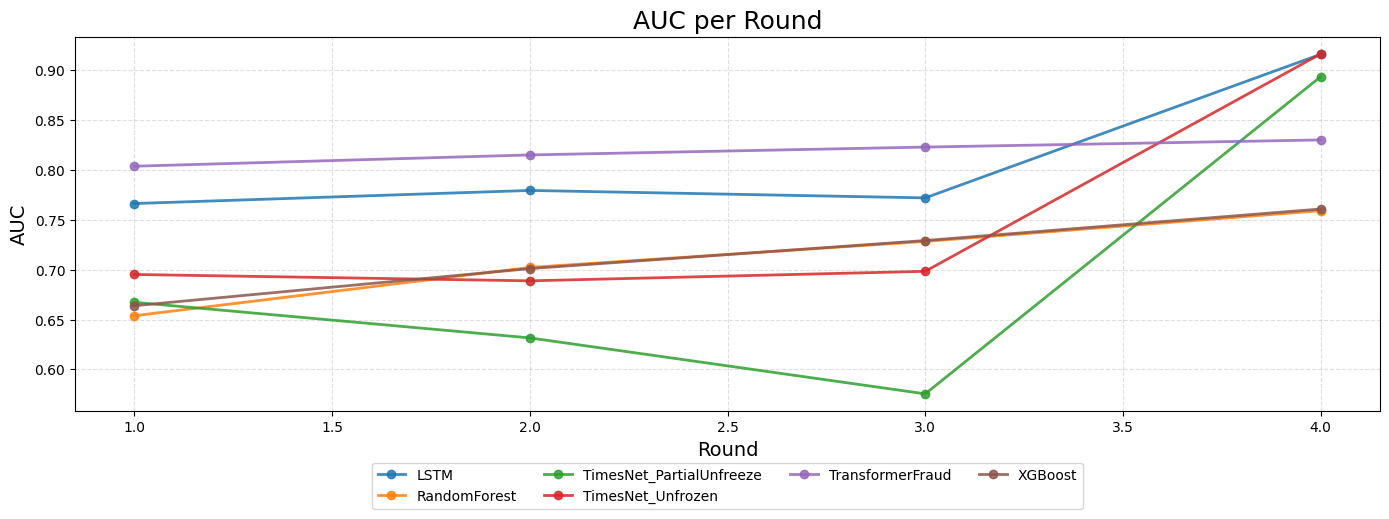

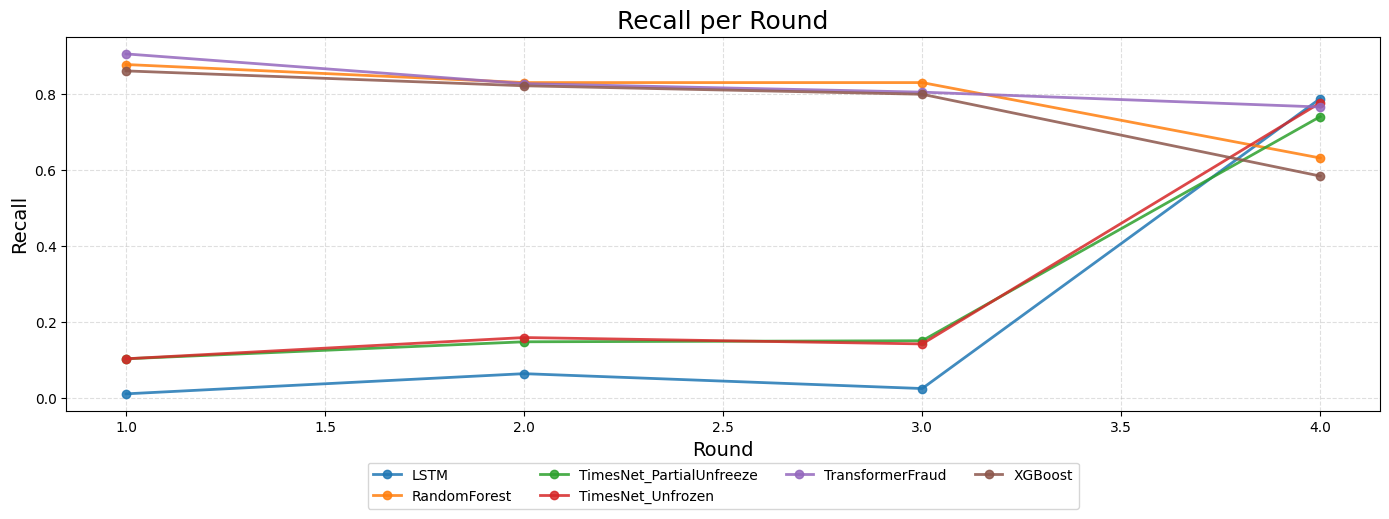

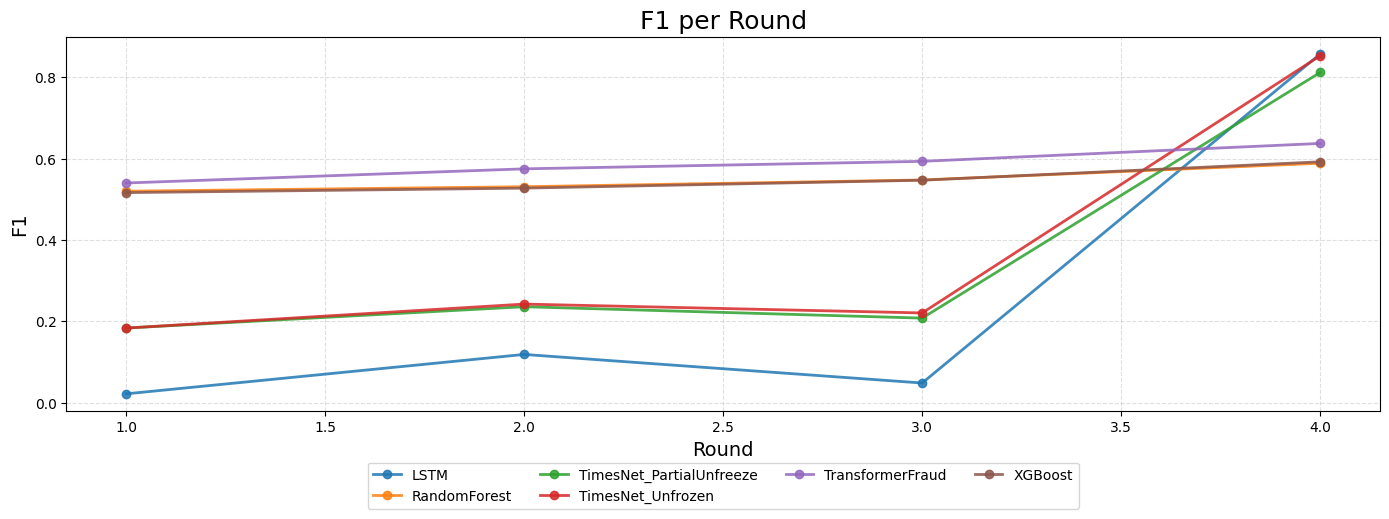

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,threshold,Round
0,4M,4,LSTM,0.022039,0.766467,0.011173,0.800000,0.61,1
1,4M,4,RandomForest,0.519868,0.653908,0.877095,0.369412,0.31,1
2,4M,4,TimesNet_PartialUnfreeze,0.183623,0.667376,0.103352,0.822222,0.54,1
3,4M,4,TimesNet_Unfrozen,0.183623,0.695303,0.103352,0.822222,0.53,1
4,4M,4,TransformerFraud,0.540000,0.803915,0.905028,0.384798,0.26,1
5,4M,4,XGBoost,0.516345,0.663948,0.860335,0.368862,0.45,1
6,4M,4,LSTM,0.118863,0.779616,0.064246,0.793103,0.61,2
7,4M,4,RandomForest,0.530831,0.702360,0.829609,0.390276,0.31,2
8,4M,4,TimesNet_PartialUnfreeze,0.236080,0.631660,0.148045,0.582418,0.54,2
9,4M,4,TimesNet_Unfrozen,0.242553,0.688918,0.159218,0.508929,0.53,2


,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold
0,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31
2,4M,4,TimesNet_PartialUnfreeze,0.8116,0.8938,0.7402,0.8983,0.54
3,4M,4,TimesNet_Unfrozen,0.8528,0.9166,0.7765,0.9456,0.53
4,4M,4,TransformerFraud,0.6372,0.8303,0.7654,0.5458,0.26
5,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45



📊 FINAL GENERALIZATION GAP RESULTS - ALL MODELS


,Model,Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold
0,LSTM,0.8437,0.8620,0.8571,-0.0183,-0.0135,0.0049,0.61
1,RandomForest,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
2,TimesNet_PartialUnfreeze,0.7917,0.8180,0.8116,-0.0263,-0.0200,0.0064,0.54
3,TimesNet_Unfrozen,0.8484,0.8479,0.8528,0.0005,-0.0044,-0.0049,0.53
4,TransformerFraud,0.6431,0.6523,0.6372,-0.0092,0.0059,0.0151,0.26
5,XGBoost,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


In [ ]:
plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col="Round"
)
summary = summary.sort_values(
        by=[ "Model"],
        ascending=True
    ).reset_index(drop=True)

display(summary)

print("\n" + "="*70)
print("📊 FINAL GENERALIZATION GAP RESULTS - ALL MODELS")
print("="*70)

display(gap_table.sort_values("Model").reset_index(drop=True))


#### Gap

#FLOP

## FLOP profiling for neural models

In [ ]:
flop_results = {}
INPUT_DIM_TIMESNET = 13
INPUT_DIM_SEQ = trans_X_train.shape[2]
NUM_CLASSES = 2
prof_device = torch.device("cpu")
PROFILE_SL = max_seq_len
timesnet_root_path = data_path
timesnet_data_name = "FraudDataset"
def flopcounter_flops(model, inputs):
    model = model.to(prof_device).eval()
    inputs = tuple(x.to(prof_device) if isinstance(x, torch.Tensor) else x for x in inputs)
    model(*inputs)
    with FlopCounterMode(display=False) as fc:
        model(*inputs)
    return fc.get_total_flops()


### Profile LSTM

In [ ]:

# ─── LSTM (ptflops — handles aten::lstm via explicit hook) ───
def _lstm_inputs(shape):
    return {"x":    torch.randn(1, *shape),
            "mask": torch.zeros(1, shape[0], dtype=torch.bool)}

L = PROFILE_SL
model = LSTMFraud(
    input_dim=INPUT_DIM_SEQ,
    hidden_dim=lstm_parameters["d_model"],
    n_layers=lstm_parameters["e_layers"],
    d_ff=lstm_parameters["d_ff"],
    dropout=0.0,
    num_classes=NUM_CLASSES
).eval()

macs, params = get_model_complexity_info(
    model, (L, INPUT_DIM_SEQ),
    input_constructor=_lstm_inputs,
    as_strings=False, print_per_layer_stat=False, verbose=False,
)
flop_results[("LSTM", L)] = 2 * macs

Warning! No positional inputs found for a module, assuming batch size is 1.


### Profile Transformer

In [ ]:
L = PROFILE_SL
model = TransformerFraud(
    input_dim=INPUT_DIM_SEQ,
    d_model=transformer_parameters["d_model"],
    n_heads=transformer_parameters["n_heads"],
    n_layers=transformer_parameters["e_layers"],
    d_ff=transformer_parameters["d_ff"],
    dropout=0.0
).eval()

for m in model.modules():
    if hasattr(m, '_fast_path_enabled'):
        m._fast_path_enabled = False

x = torch.randn(1, L, INPUT_DIM_SEQ)
mask = torch.zeros(1, L, dtype=torch.bool)
flop_results[("Transformer", L)] = flopcounter_flops(model, (x, None, mask))

### Profile TimesNet

In [ ]:

L = PROFILE_SL
cfg = Namespace(
    task_name='classification',
    seq_len=L, label_len=48, pred_len=0,
    e_layers=timesnet_parameters["e_layers"],
    d_model=timesnet_parameters["d_model"],
    d_ff=timesnet_parameters["d_ff"],
    top_k=timesnet_parameters["top_k"],
    num_kernels=timesnet_parameters["num_kernels"],
    enc_in=INPUT_DIM_TIMESNET, c_out=INPUT_DIM_TIMESNET,
    embed='timeF', freq='h',
    dropout=timesnet_parameters["dropout"],
    num_class=NUM_CLASSES,
    n_heads=8, d_layers=1, factor=1, distil=True, activation='gelu',
)

model = TimesNetModel(cfg).to(prof_device).eval()

args = Namespace(
    task_name='classification',
    root_path=timesnet_root_path,
    data_path=timesnet_data_name,
    data='UEA',
    seq_len=L, label_len=48, pred_len=0,
    features='M', target='OT', embed='timeF', freq='h',
    batch_size=1, num_workers=0, seasonal_patterns='Monthly',
    augmentation_ratio=0,
)

_, loader = data_provider(args, flag='TEST')
x, _, padding_mask = next(iter(loader))
x, padding_mask = x.to(prof_device), padding_mask.to(prof_device)

model(x, padding_mask, None, None)
with FlopCounterMode(display=False) as fc:
    model(x, padding_mask, None, None)

flop_results[("TimesNet", L)] = fc.get_total_flops()

### RF & XGB

In [ ]:


def count_rf_comparisons(rf):
    """Sum of max tree depths = worst-case comparisons per sample."""
    return sum(tree.tree_.max_depth for tree in rf.estimators_)

def count_xgb_comparisons(xgb):
    """Sum of internal (non-leaf) nodes across all trees."""
    trees = xgb.get_booster().trees_to_dataframe()
    internal_per_tree = trees.groupby("Tree").apply(
        lambda df: df["Feature"].ne("Leaf").sum()
    )
    return int(internal_per_tree.sum())

def measure_sklearn_latency(model, X, n_repeat=100, n_warmup=10):
    single = X[:1]
    for _ in range(n_warmup):
        model.predict_proba(single)
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        model.predict_proba(single)
        times.append(time.perf_counter() - t0)
    return round(np.median(times) * 1e6, 2)  # μs



# Fit and measure one RF per SL
tree_results = {}

SL = PROFILE_SL

tree_results[("RandomForest", SL)] = {
    "n_trees": rf_parameters["n_estimators"],
    "comparisons": count_rf_comparisons(rf_model),
    "latency_us": measure_sklearn_latency(rf_model, X_test_scaled),
}

print(
    f"RF SL{SL}: trees={tree_results[('RandomForest', SL)]['n_trees']}, "
    f"comparisons={tree_results[('RandomForest', SL)]['comparisons']}, "
    f"latency={tree_results[('RandomForest', SL)]['latency_us']} μs"
)

tree_results[("XGBoost", SL)] = {
    "n_trees": xgb_parameters["n_estimators"],
    "comparisons": count_xgb_comparisons(xgb_model),
    "latency_us": measure_sklearn_latency(xgb_model, X_test_scaled),
}

print(
    f"XGB SL{SL}: trees={tree_results[('XGBoost', SL)]['n_trees']}, "
    f"comparisons={tree_results[('XGBoost', SL)]['comparisons']}, "
    f"latency={tree_results[('XGBoost', SL)]['latency_us']} μs"
)


RF SL4: trees=200, comparisons=1000, latency=25724.45 μs
XGB SL4: trees=500, comparisons=2269, latency=505.26 μs


##  Latency

In [ ]:


# ============================================================
# NN CPU latency (for fair comparison with tree models)
# ============================================================
@torch.no_grad()
def measure_nn_latency_cpu(model, inputs_fn, n_repeat=100, n_warmup=10):
    model.eval().to("cpu")
    for _ in range(n_warmup):
        model(*inputs_fn())
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        model(*inputs_fn())
        times.append(time.perf_counter() - t0)
    return round(np.median(times) * 1e6, 2)  # μs


nn_latency = {}
L = PROFILE_SL

# LSTM
m = LSTMFraud(
    input_dim=INPUT_DIM_SEQ,
    hidden_dim=lstm_parameters["d_model"],
    n_layers=lstm_parameters["e_layers"],
    d_ff=lstm_parameters["d_ff"],
    dropout=0.0,
    num_classes=NUM_CLASSES
)
nn_latency[("LSTM", L)] = measure_nn_latency_cpu(
    m,
    lambda: (
        torch.randn(1, L, INPUT_DIM_SEQ),
        torch.zeros(1, L, dtype=torch.bool),
    ),
)

# Transformer
m = TransformerFraud(
    input_dim=INPUT_DIM_SEQ,
    d_model=transformer_parameters["d_model"],
    n_heads=transformer_parameters["n_heads"],
    n_layers=transformer_parameters["e_layers"],
    d_ff=transformer_parameters["d_ff"],
    dropout=0.0
)
nn_latency[("Transformer", L)] = measure_nn_latency_cpu(
    m,
    lambda: (
        torch.randn(1, L, INPUT_DIM_SEQ),
        None,
        torch.zeros(1, L, dtype=torch.bool),
    ),
)

# TimesNet
cfg = Namespace(
    task_name='classification',
    seq_len=L, label_len=48, pred_len=0,
    e_layers=timesnet_parameters["e_layers"],
    d_model=timesnet_parameters["d_model"],
    d_ff=timesnet_parameters["d_ff"],
    top_k=timesnet_parameters["top_k"],
    num_kernels=timesnet_parameters["num_kernels"],
    enc_in=INPUT_DIM_TIMESNET, c_out=INPUT_DIM_TIMESNET,
    embed='timeF', freq='h',
    dropout=timesnet_parameters["dropout"],
    num_class=NUM_CLASSES,
    n_heads=8, d_layers=1, factor=1, distil=True, activation='gelu',
)
m = TimesNetModel(cfg).to(prof_device).eval()

args = Namespace(
    task_name='classification',
    root_path=timesnet_root_path,
    data_path=timesnet_data_name,
    data='UEA',
    seq_len=L, label_len=48, pred_len=0,
    features='M', target='OT', embed='timeF', freq='h',
    batch_size=1, num_workers=0, seasonal_patterns='Monthly',
    augmentation_ratio=0,
)


_, loader = data_provider(args, flag='TEST')
x, _, pm = next(iter(loader))

nn_latency[("TimesNet", L)] = measure_nn_latency_cpu(
    m,
    lambda x=x, pm=pm: (x, pm, None, None),
)

## Summary

In [ ]:
rows = []

# Neural models — keyed by (model, SL)
for (m, sl), fl in flop_results.items():
    rows.append({"Model": m, "SL": sl,
                 "FLOPs": fl, "MFLOPs": round(fl/1e6, 4),
                 "Comparisons": "—",
                 "Latency (μs)": nn_latency.get((m, sl), "—")})

# Tree models — keyed by (model, SL), same structure as neural
for (m, sl), info in tree_results.items():
    rows.append({"Model": m, "SL": sl,
                 "FLOPs": "—", "MFLOPs": "—",
                 "Comparisons": info["comparisons"],
                 "Latency (μs)": info["latency_us"]})

df_combined = pd.DataFrame(rows).sort_values(["Model", "SL"]).reset_index(drop=True)
# Align cost table names to match summary names
name_map = {
    "TimesNet": "TimesNet_Unfrozen",
    "Transformer": "TransformerFraud",
}
df_combined["Model"] = df_combined["Model"].replace(name_map)

# Add a second row for PartialUnfreeze (same cost as Unfrozen — same architecture)
tn_row = df_combined[df_combined["Model"] == "TimesNet_Unfrozen"].copy()
tn_row["Model"] = "TimesNet_PartialUnfreeze"
df_combined = pd.concat([df_combined, tn_row], ignore_index=True)

final_report = pd.merge( summary,df_combined, on='Model', how='inner')
final_report = pd.merge( final_report,gap_table, on='Model', how='inner')
final_report.to_csv("final_report_all_models.csv", index=False)

display(final_report)

# df_combined.to_csv("compute_cost_all_models.csv", index=False)
# display(df_combined)

,NAS SL,Testing SL,Model,F1,AUC,Recall,Precision,Threshold_x,SL,FLOPs,MFLOPs,Comparisons,Latency (μs),Train_F1,Val_F1,Test_F1,Train_vs_Val_Gap,Train_vs_Test_Gap,Val_vs_Test_Gap,Threshold_y
0,4M,4,LSTM,0.8571,0.9162,0.7877,0.9400,0.61,4,717060,0.7171,—,862.66,0.8437,0.8620,0.8571,-0.0183,-0.0135,0.0049,0.61
1,4M,4,RandomForest,0.5885,0.7593,0.6313,0.5512,0.31,4,—,—,1000,25724.45,0.5957,0.5851,0.5885,0.0106,0.0072,-0.0035,0.31
2,4M,4,TimesNet_PartialUnfreeze,0.8116,0.8938,0.7402,0.8983,0.54,4,18753792,18.7538,—,9782.02,0.7917,0.8180,0.8116,-0.0263,-0.0200,0.0064,0.54
3,4M,4,TimesNet_Unfrozen,0.8528,0.9166,0.7765,0.9456,0.53,4,18753792,18.7538,—,9782.02,0.8484,0.8479,0.8528,0.0005,-0.0044,-0.0049,0.53
4,4M,4,TransformerFraud,0.6372,0.8303,0.7654,0.5458,0.26,4,157072,0.1571,—,1486.61,0.6431,0.6523,0.6372,-0.0092,0.0059,0.0151,0.26
5,4M,4,XGBoost,0.5921,0.7610,0.5838,0.6006,0.45,4,—,—,2269,505.26,0.5942,0.5773,0.5921,0.0169,0.0021,-0.0147,0.45


## Graph Summary

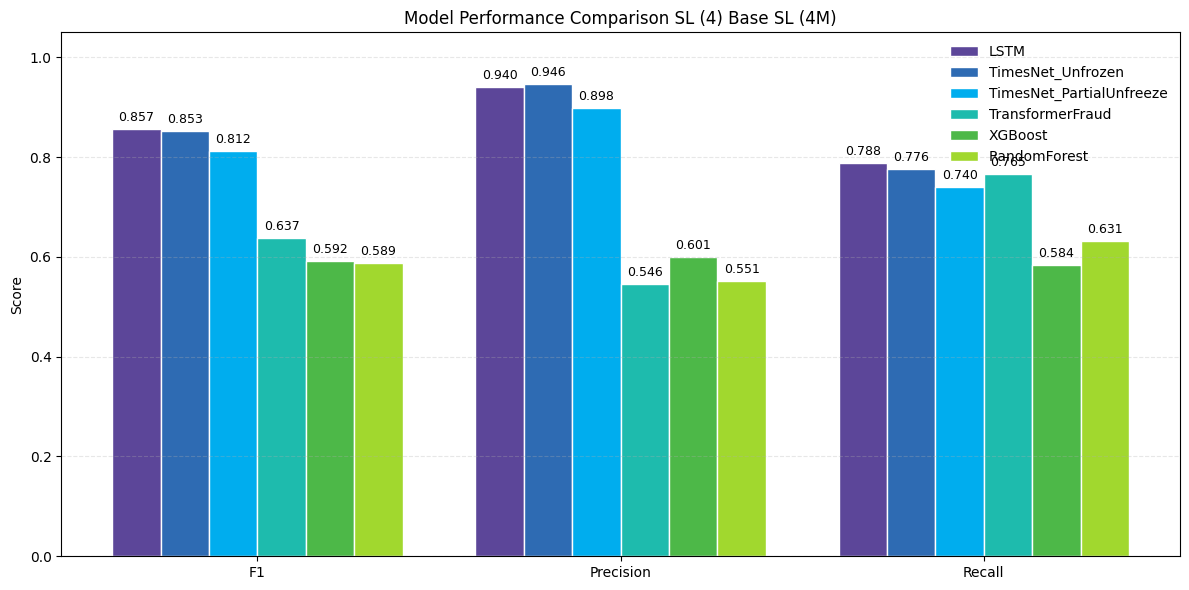

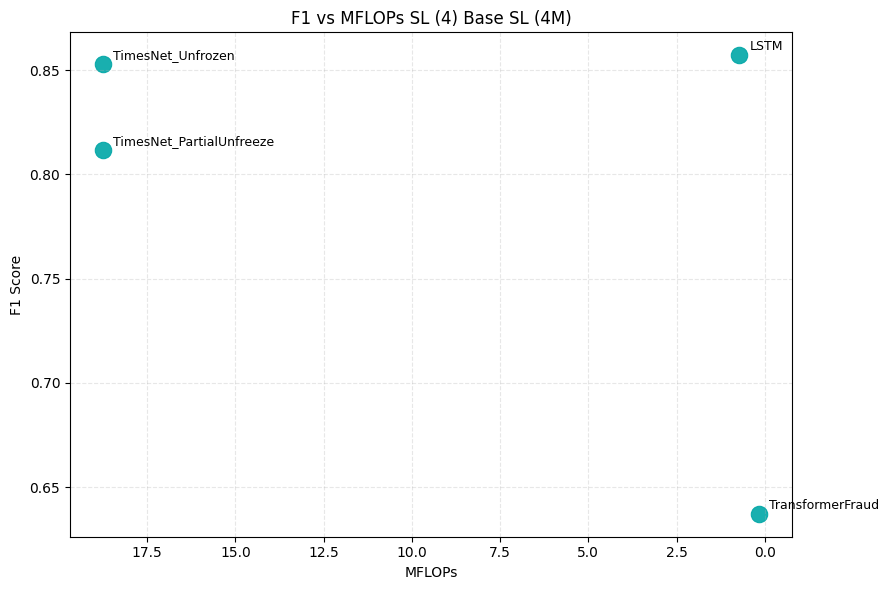

In [ ]:

plt.style.use("default")

# =========================
# 1) Bar chart: F1 / Precision / Recall
# =========================
metrics_df = final_report[["Model", "F1", "Precision", "Recall"]].copy()
metrics_df = metrics_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
metrics = ["F1", "Precision", "Recall"]
models = metrics_df["Model"].values

x = np.arange(len(metrics))
width = 0.8 / len(models)  # dynamic width based on number of models

plt.figure(figsize=(12, 6))

bars_all = []
colors = ["#5C4699", "#2E6BB3", "#00ADEE", "#1EBBAD", "#4DB848", "#A1D82E"]
#colors = ["#2D527C", "#3E8E91", "#7BB3B5", "#A8D5BA", "#F2E8CF", "#E76F51"]
#colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#8D99AE"]
for i, model in enumerate(models):
    values = metrics_df.loc[metrics_df["Model"] == model, metrics].values.flatten()

    bars = plt.bar(
        x + (i - len(models)/2) * width + width/2,
        values,
        width,
        label=model,
        color=colors[i],   # 👈 correct
        edgecolor="white",

    )
    bars_all.append(bars)

# X-axis = metrics
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title(f"Model Performance Comparison SL ({max_seq_len}) Base SL ({Base_SL})")
plt.ylim(0, 1.05)
plt.legend(frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Labels on bars
for bars in bars_all:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()
# =========================
# 2) F1 vs MFLOPs
#    Only models with real MFLOPs
# =========================

cost_df = final_report.copy()
cost_df["MFLOPs"] = pd.to_numeric(cost_df["MFLOPs"], errors="coerce")

# Do NOT fill XGB/RF. Drop models without real MFLOPs.
cost_df = cost_df.dropna(subset=["MFLOPs", "F1"]).copy()
cost_df = cost_df.sort_values(by="MFLOPs", ascending=True)
x_range = cost_df["MFLOPs"].max() - cost_df["MFLOPs"].min()
y_range = cost_df["F1"].max() - cost_df["F1"].min()

x_offset = x_range * 0.015
y_offset = y_range * 0.02


plt.figure(figsize=(9, 6))

plt.scatter(
    cost_df["MFLOPs"],
    cost_df["F1"],
    s=140,
    color="#00A6A6",   # purple
    #edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)

for _, row in cost_df.iterrows():
    x = row["MFLOPs"]
    y = row["F1"]

    # Shift label LEFT (since axis is inverted)
    plt.text(
        x - x_offset,   # move left
        y + 0.001,  # slight vertical offset
        row["Model"],
        fontsize=9,
        ha="left",   # align text properly
        va="bottom"
    )

plt.xlabel("MFLOPs")
plt.ylabel("F1 Score")
plt.title(f"F1 vs MFLOPs SL ({max_seq_len}) Base SL ({Base_SL})")
plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().invert_xaxis()  # makes "better" direction visually left
plt.tight_layout()
plt.show()

#freeze

In [ ]:
%pip freeze > "{project_path}requirement/freez/NASEnhancedPretraindMLModleAdvance-lock.txt"

In [ ]:
end = time.time()
elapsed = end - start_time

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"Total Time = {hours}h {minutes}m {seconds}s")

Total Time = 0h 22m 26s
